In [ ]:
'''
참고사항

1. weights & bias api 필요
2. google drive에 dataset이랑 checkpoint 필요
  ex)
    - checkpoint path: /content/drive/MyDrive/checkpoints/toss.ckpt
    - dataset path: /content/drive/MyDrive/datasets/TOSS_Dataset/portrait4d_rembg

3. Training 후에는 checkpoint를 google drive에 저장
  ex)
    - /content/drive/MyDrive/checkpoints/toss_lora/last.ckpt
'''

'\n참고사항\n\n1. weights & bias api 필요\n2. google drive에 dataset이랑 checkpoint 필요\n  ex)\n    - checkpoint path: /content/drive/MyDrive/checkpoints/toss.ckpt\n    - dataset path: /content/drive/MyDrive/datasets/TOSS_Dataset/portrait4d_rembg\n\n3. Training 후에는 checkpoint를 google drive에 저장\n  ex)\n    - /content/drive/MyDrive/checkpoints/toss_lora/last.ckpt\n'

In [ ]:
# !git clone https://github.com/wndyd0131/TOSS-Human-Novel-Views.git
!git clone -b feat/train_correlation https://github.com/wndyd0131/TOSS-Human-Novel-Views.git
# !git clone -b train_depth https://github.com/wndyd0131/TOSS-Human-Novel-Views.git

Cloning into 'TOSS-Human-Novel-Views'...
remote: Enumerating objects: 759, done.
remote: Counting objects: 100% (759/759), done.
remote: Compressing objects: 100% (540/540), done.
remote: Total 759 (delta 285), reused 649 (delta 175), pack-reused 0 (from 0)
Receiving objects: 100% (759/759), 21.86 MiB | 26.71 MiB/s, done.
Resolving deltas: 100% (285/285), done.


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

# import os
# os.environ["PIP_CACHE_DIR"] = "/content/drive/MyDrive/pip_cache"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1 --index-url https://download.pytorch.org/whl/cu121
%cd TOSS-Human-Novel-Views
!pip install -r requirements.txt
!git clone https://github.com/openai/CLIP.git
!pip install -e CLIP/

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.9/798.9 MB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 146.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 117.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 112.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 60.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 136.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 20.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 43.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 20.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/1

Cloning into 'CLIP'...
remote: Enumerating objects: 265, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 265 (delta 1), reused 0 (delta 0), pack-reused 260 (from 2)
Receiving objects: 100% (265/265), 8.87 MiB | 30.29 MiB/s, done.
Resolving deltas: 100% (137/137), done.
Obtaining file:///content/TOSS-Human-Novel-Views/CLIP
  Preparing metadata (setup.py) ... done
  Running setup.py develop for clip


In [ ]:
# 1. 기존에 꼬여있을 수 있는 패키지 삭제
!pip uninstall -y transformers peft tokenizers huggingface_hub

# 2. Python 3.12 및 최신 코랩 환경에서 호환되는 안정적인 버전 조합 설치
!pip install "transformers==4.40.2" "peft==0.10.0" "tokenizers==0.19.1" "huggingface_hub==0.23.0"
!pip install "numpy<2.0" "protobuf==4.25.3" "wandb==0.24.1"

# 3. (선택) 아까 로그에 없다고 나왔던 xformers도 버전에 맞게 매칭해줍니다.
!pip install xformers --index-url https://download.pytorch.org/whl/cu121

Found existing installation: transformers 4.57.3
Uninstalling transformers-4.57.3:
  Successfully uninstalled transformers-4.57.3
Found existing installation: peft 0.17.1
Uninstalling peft-0.17.1:
  Successfully uninstalled peft-0.17.1
Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2
Found existing installation: huggingface_hub 0.36.2
Uninstalling huggingface_hub-0.36.2:
  Successfully uninstalled huggingface_hub-0.36.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 123.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 129.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.2/401.2 kB 35.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are instal

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 13.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.6/209.6 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 101.2 MB/s eta 0:00:00
  Attempting uninstall: triton
    Found existing installation: triton 3.0.0
    Uninstalling triton-3.0.0:
      Successfully uninstalled triton-3.0.0
  Attempting uninstall: sympy
    Found existing installation: sympy 1.14.0
    Uninstalling sympy-1.14.0:
      Successfully uninstalled sympy-1.14.0
  Attempting uninstall: nvidia-nccl-cu12
    Found existing installation: nvidia-nccl-cu12 2.20.5
    Uninstalling nvidia-nccl-cu12-2.20.5:
      Successfully uninstalled nvidia-nccl-cu12-2.20.5
  Attempting uninstall: torch
    Found exi

In [ ]:
!wget -q -O /usr/weights.pt https://github.com/dingkeyan93/DISTS/raw/master/DISTS_pytorch/weights.pt
!ls -la /usr/weights.pt

-rw-r--r-- 1 root root 12288 Jun 26 11:05 /usr/weights.pt


In [ ]:
%cd /content/TOSS-Human-Novel-Views

/content/TOSS-Human-Novel-Views


# Load Model (Training)

In [ ]:
import torch
from cldm.toss import TOSS
from cldm.model import load_state_dict
from omegaconf import OmegaConf

from ldm.util import instantiate_from_config


config = OmegaConf.load("models/toss_vae.yaml")
model = instantiate_from_config(config.model)
lora_config_params = model.model.diffusion_model.peft_config['default']

checkpoint_path = "/content/drive/MyDrive/checkpoints/toss.ckpt"
# 1. Get raw state dict
raw_sd = torch.load(checkpoint_path, map_location="cpu", weights_only=False)["state_dict"] # Load parameters from checkpoint
new_sd = {}

true_count = 0
false_count = 0
# 2. Targeted Remapping
for k, v in raw_sd.items():
    # Fix the PEFT wrapper prefix first
    nk = k.replace("model.diffusion_model.", "model.diffusion_model.base_model.model.")

    # CRITICAL: If this is a LoRA target module, it MUST end in .base_layer.weight
    # Check if the original key (k) contains any of your target module names
    is_target = any(target in k for target in lora_config_params.target_modules)

    if is_target:
        true_count += 1
        # e.g., to_q.weight -> to_q.base_layer.weight
        nk = nk.replace(".weight", ".base_layer.weight")
        nk = nk.replace(".bias", ".base_layer.bias")
    else:
        false_count += 1
    new_sd[nk] = v

/usr/local/lib/python3.12/dist-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/distributed.py:258: LightningDeprecationWarning: `pytorch_lightning.utilities.distributed.rank_zero_only` has been deprecated in v1.8.1 and will be removed in v2.0.0. You can import it from `pytorch_lightning.utilities` instead.
  rank_zero_deprecation(


[PATCH] Disabled gradient checkpointing in ldm_util.checkpoint
TossLoraModule: Running in eps-prediction mode
Setting up MemoryEfficientCrossAttention. Query dim is 320, context_dim is None and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 320, context_dim is 768 and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 320, context_dim is None and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 320, context_dim is 768 and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 640, context_dim is None and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 640, context_dim is 768 and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 640, context_dim is None and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 640, context_dim is 768 and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 1280, context_dim is None and using 8 heads.
Se

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: wndyd0131 (wndyd0131-sungkyunkwan-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


[INIT] Unfreezing pose_net param: base_model.model.pose_net.0.weight, shape=torch.Size([320, 51])
[INIT] Unfreezing pose_net param: base_model.model.pose_net.0.bias, shape=torch.Size([320])
[INIT] Unfreezing pose_net param: base_model.model.pose_net.2.weight, shape=torch.Size([320, 320])
[INIT] Unfreezing pose_net param: base_model.model.pose_net.2.bias, shape=torch.Size([320])
[INIT] Unfroze 4 pose_net parameters
[INIT] Unfroze vae_proj parameters
[INIT] Enabled requires_grad for 128 LoRA parameters
  -> base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_q.lora_A.default.weight: shape=torch.Size([16, 320]), requires_grad=True
  -> base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_q.lora_B.default.weight: shape=torch.Size([320, 16]), requires_grad=True
  -> base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_k.lora_A.default.weight: shape=torch.Size([16, 320]), requires_grad=True
  -> base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to

In [ ]:
# 3. Load into model
missing, unexpected = model.load_state_dict(new_sd, strict=False) # Iteratre through state_dict and match the params
print("Missing:", missing) # Keys that the model has but the state_dict does not
print("Unexpected:", unexpected) # Keys that the model does not have but the state_dict does
print("True Count:", true_count)
print("False Count:", false_count)

# 4. Verify: Only lora_A/lora_B should be missing now
final_missing = [m for m in missing if "lora_" not in m]
print(f"CRITICAL MISSING (Should be empty): {final_missing}")

Missing: ['model.diffusion_model.base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_q.lora_A.default.weight', 'model.diffusion_model.base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_q.lora_B.default.weight', 'model.diffusion_model.base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_k.lora_A.default.weight', 'model.diffusion_model.base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_k.lora_B.default.weight', 'model.diffusion_model.base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_v.lora_A.default.weight', 'model.diffusion_model.base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_v.lora_B.default.weight', 'model.diffusion_model.base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_out.0.lora_A.default.weight', 'model.diffusion_model.base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_out.0.lora_B.default.weight', 'model.diffusion_model.base_model.model.input_blocks.2.1.transformer_blocks.0.

In [ ]:
print(model)

TossLoraModule(
  (model): DiffusionWrapper(
    (diffusion_model): PeftModel(
      (base_model): LoraModel(
        (model): UNetModel_toss(
          (time_embed): Sequential(
            (0): Linear(in_features=320, out_features=1280, bias=True)
            (1): SiLU()
            (2): Linear(in_features=1280, out_features=1280, bias=True)
          )
          (input_blocks): ModuleList(
            (0): TimestepEmbedSequential(
              (0): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            )
            (1-2): 2 x TimestepEmbedSequential(
              (0): ResBlock(
                (in_layers): Sequential(
                  (0): GroupNorm32(32, 320, eps=1e-05, affine=True)
                  (1): SiLU()
                  (2): Conv2d(320, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
                )
                (h_upd): Identity()
                (x_upd): Identity()
                (emb_layers): Sequential(
                  (0): S

In [ ]:
trainable = [n for n, p in model.named_parameters() if p.requires_grad]
print("Trainable parameters:", len(trainable))
for n in trainable:
    print(n)

Trainable parameters: 252
model.diffusion_model.base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_q.lora_A.default.weight
model.diffusion_model.base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_q.lora_B.default.weight
model.diffusion_model.base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_k.lora_A.default.weight
model.diffusion_model.base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_k.lora_B.default.weight
model.diffusion_model.base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_v.lora_A.default.weight
model.diffusion_model.base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_v.lora_B.default.weight
model.diffusion_model.base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_out.0.lora_A.default.weight
model.diffusion_model.base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_out.0.lora_B.default.weight
model.diffusion_model.base_model.model.input_blocks.1.1.transformer_blocks.0.vae_proj.

# Pose Methods

In [ ]:
import numpy as np

def rotation_matrix_to_euler(R):
    """
    Extract pitch (x-rotation) and yaw (y-rotation) from a 3x3 rotation matrix.
    Returns angles in radians.

    Assumes rotation order: R = Ry(yaw) @ Rx(pitch) @ Rz(roll)
    """
    # Clamp to avoid numerical issues with asin
    sy = np.clip(R[0, 2], -1.0, 1.0)
    yaw = np.arcsin(sy)

    # Check for gimbal lock
    if np.abs(sy) < 0.99999:
        pitch = np.arctan2(-R[1, 2], R[2, 2])
    else:
        pitch = np.arctan2(R[2, 1], R[1, 1])

    return pitch, yaw


def pose_matrix_to_toss_format(pose_4x4):
    """
    Convert a 4x4 pose matrix to TOSS format: [pitch, yaw, distance]

    Args:
        pose_4x4: 4x4 transformation matrix (camera-to-world or world-to-camera)

    Returns:
        [pitch, yaw, distance] as expected by TOSS pose_enc="vae" or "freq"
    """
    R = pose_4x4[:3, :3]  # 3x3 rotation
    t = pose_4x4[:3, 3]   # translation vector

    pitch, yaw = rotation_matrix_to_euler(R)

    # Distance: typically the Z component or the norm of translation
    # Adjust based on your coordinate system
    distance = np.linalg.norm(t)  # or t[2] if Z is the depth axis

    return np.array([pitch, yaw, distance], dtype=np.float32)

def _wrap_angle(angle: float) -> float:
    return float(np.arctan2(np.sin(angle), np.cos(angle)))


def compute_relative_pose(
    src_pose_4x4: np.ndarray, tgt_pose_4x4: np.ndarray
) -> np.ndarray:
    """
    Relative [delta_pitch, delta_yaw, delta_distance] in radians.
    Nersemble yaw sign is flipped to match Portrait4D/TOSS convention.
    """
    src_pitch, src_yaw = rotation_matrix_to_euler(src_pose_4x4[:3, :3])
    tgt_pitch, tgt_yaw = rotation_matrix_to_euler(tgt_pose_4x4[:3, :3])

    delta_pitch = _wrap_angle(tgt_pitch - src_pitch)

    # Nersemble: left-looking image gives negative yaw,
    # Portrait4D/TOSS: left-looking image gives positive yaw.
    delta_yaw = -_wrap_angle(tgt_yaw - src_yaw)

    src_dist = float(np.linalg.norm(src_pose_4x4[:3, 3]))
    tgt_dist = float(np.linalg.norm(tgt_pose_4x4[:3, 3]))

    return np.array(
        [delta_pitch, delta_yaw, tgt_dist - src_dist],
        dtype=np.float32,
    )


# def compute_relative_pose(src_pose_4x4, tgt_pose_4x4):
#     """
#     Compute relative pose from source to target view.
#     Returns [delta_pitch, delta_yaw, delta_distance] in radians.
#     """
#     src_pitch, src_yaw = rotation_matrix_to_euler(src_pose_4x4[:3, :3])
#     tgt_pitch, tgt_yaw = rotation_matrix_to_euler(tgt_pose_4x4[:3, :3])

#     src_dist = np.linalg.norm(src_pose_4x4[:3, 3])
#     tgt_dist = np.linalg.norm(tgt_pose_4x4[:3, 3])

#     delta_pitch = tgt_pitch - src_pitch
#     delta_yaw = tgt_yaw - src_yaw
#     delta_distance = tgt_dist - src_dist

#     return np.array([delta_pitch, delta_yaw, delta_distance], dtype=np.float32)

# Debug: Check poses.npy format and values
import numpy as np

sub_path = "/content/drive/MyDrive/datasets/TOSS_Dataset/portrait4d_rembg_isnet_v2/202501"
# sub_path = "/content/drive/MyDrive/datasets/TOSS_Dataset/nersemble_v2/017"
poses = np.load(f"{sub_path}/poses.npy")

print(f"Poses shape: {poses.shape}")
print(f"Poses dtype: {poses.dtype}")

# Reshape if needed
if poses.ndim == 2 and poses.shape[1] == 16:
    poses = poses.reshape(-1, 4, 4)
    print(f"Reshaped to: {poses.shape}")

src_idx = 0

print("\nRelative pose values:")
for i in range(len(poses)):
    rel = compute_relative_pose(poses[src_idx], poses[i])
    print(
        f"View {i:02d}: "
        f"d_pitch={np.degrees(rel[0]):+7.2f}°, "
        f"d_yaw={np.degrees(rel[1]):+7.2f}°, "
        f"d_dist={rel[2]:+.4f}"
    )

# Check a single pose matrix
print(f"\nPose[0] (view 00000):\n{poses[0]}")
print(f"\nPose[9] (view 00009 - center):\n{poses[9]}")

# Check if it looks like a valid rotation matrix
R = poses[0][:3, :3]
print(f"\nRotation matrix R (from pose[0]):\n{R}")
print(f"det(R) = {np.linalg.det(R):.6f} (should be ~1.0 for valid rotation)")
print(f"R @ R.T =\n{R @ R.T} (should be ~identity)")

# Extract angles using your function
pitch, yaw = rotation_matrix_to_euler(R)
print(f"\nExtracted angles from pose[0]:")
print(f"  pitch = {pitch:.4f} rad = {np.degrees(pitch):.2f}°")
print(f"  yaw = {yaw:.4f} rad = {np.degrees(yaw):.2f}°")

# Check all poses' yaw values
print(f"\nAll yaw values (degrees):")
for i in range(min(20, len(poses))):
    p, y = rotation_matrix_to_euler(poses[i][:3, :3])
    print(f"  View {i:02d}: pitch={np.degrees(p):+7.2f}°, yaw={np.degrees(y):+7.2f}°")

Poses shape: (20, 16)
Poses dtype: float32
Reshaped to: (20, 4, 4)

Relative pose values:
View 00: d_pitch=  +0.00°, d_yaw=  -0.00°, d_dist=+0.0000
View 01: d_pitch=  -0.00°, d_yaw=  +1.90°, d_dist=+0.0000
View 02: d_pitch=  -0.00°, d_yaw=  +3.79°, d_dist=+0.0000
View 03: d_pitch=  -0.00°, d_yaw=  +5.69°, d_dist=+0.0000
View 04: d_pitch=  -0.00°, d_yaw=  +7.59°, d_dist=+0.0000
View 05: d_pitch=  -0.00°, d_yaw=  +9.49°, d_dist=+0.0000
View 06: d_pitch=  -0.00°, d_yaw= +11.38°, d_dist=+0.0000
View 07: d_pitch=  -0.00°, d_yaw= +13.28°, d_dist=+0.0000
View 08: d_pitch=  -0.00°, d_yaw= +15.18°, d_dist=+0.0000
View 09: d_pitch=  -0.00°, d_yaw= +17.08°, d_dist=+0.0000
View 10: d_pitch=  -0.00°, d_yaw= +18.98°, d_dist=+0.0000
View 11: d_pitch=  -0.00°, d_yaw= +20.88°, d_dist=+0.0000
View 12: d_pitch=  -0.00°, d_yaw= +22.78°, d_dist=+0.0000
View 13: d_pitch=  -0.00°, d_yaw= +24.68°, d_dist=+0.0000
View 14: d_pitch=  -0.00°, d_yaw= +26.58°, d_dist=+0.0000
View 15: d_pitch=  -0.00°, d_yaw= +28.48

# Portrait4D Dataset

In [ ]:
# import os
# from PIL import Image
# from torch.utils.data import Dataset
# import numpy as np
# import torch
# from torchvision import transforms as T

# import os

# def preprocess_normal_for_cosine(normal_rgb, valid_eps=0.1):
#     """
#     Preprocess normal map for cosine similarity loss.

#     Args:
#         normal_rgb: [H, W, 3] or [3, H, W], values in [0, 1] (standard normal map: RGB = xyz)
#         valid_eps: pixels with magnitude < valid_eps in [0,1] space are invalid (e.g. black)

#     Returns:
#         normal: [3, H, W] L2-normalized, in [-1, 1] range
#         valid_mask: [1, H, W] float, 1 where valid, 0 where invalid
#     """
#     if isinstance(normal_rgb, np.ndarray):
#         normal = torch.from_numpy(normal_rgb).float()
#     else:
#         normal = normal_rgb.float()

#     if normal.ndim == 3 and normal.shape[-1] == 3:
#         normal = normal.permute(2, 0, 1)  # HWC -> CHW

#     # Valid region: pixels where magnitude in [0,1] space > eps (exclude black/invalid)
#     mag = normal.norm(dim=0, keepdim=True)
#     valid_mask = (mag.squeeze(0) > valid_eps).float().unsqueeze(0)

#     # RGB [0, 1] -> xyz [-1, 1]
#     normal = normal * 2.0 - 1.0

#     # L2 normalize per pixel (for cosine similarity)
#     norm = normal.norm(dim=0, keepdim=True).clamp(min=1e-8)
#     normal = normal / norm

#     return normal, valid_mask

# def preprocess_image(input_im):
#     '''
#     :param input_im (PIL Image).
#     :return input_im (H, W, 3) array in [0, 1].
#     '''
#     input_im = input_im.resize([256, 256], Image.Resampling.LANCZOS)
#     input_im = np.asarray(input_im, dtype=np.float32) / 255.0
#     # (H, W, 4) array in [0, 1].

#     # old method: thresholding background, very important
#     # input_im[input_im[:, :, -1] <= 0.9] = [1., 1., 1., 1.]

#     # new method: apply correct method of compositing to avoid sudden transitions / thresholding
#     # (smoothly transition foreground to white background based on alpha values)
#     if input_im.shape[-1] == 4:
#         alpha = input_im[:, :, 3:4]
#         white_im = np.ones_like(input_im)
#         input_im = alpha * input_im + (1.0 - alpha) * white_im

#     input_im = input_im[:, :, 0:3]
#     # (H, W, 3) array in [0, 1].

#     return input_im

# def _normal_to_rgb_vis(norm):
#     """Map unit normal field to RGB in [0,1] for visualization. norm: [B,3,H,W] or [3,H,W]. Returns [3,H,W]."""
#     if norm.dim() == 4:
#         norm = norm[0]
#     return torch.clamp((norm + 1) / 2, 0, 1)

# class Portrait4dDataset(Dataset):
#     def __init__(self, root_dir, transform=None, src_view_idx=9, skip_identity=True,
#                  load_normals=True, load_depth=False):
#         super().__init__()
#         self.root_dir = root_dir
#         self.transform = transform
#         self.src_view_idx = src_view_idx
#         self.skip_identity = skip_identity
#         self.load_normals = load_normals
#         self.load_depth = load_depth

#         self.subjects = sorted([
#             d for d in os.listdir(root_dir)
#             if os.path.isdir(os.path.join(root_dir, d))
#         ])
#         self.samples = []
#         skipped = 0

#         for sub in self.subjects:
#             sub_path = os.path.join(root_dir, sub)
#             poses_path = os.path.join(sub_path, 'poses.npy')
#             if not os.path.exists(poses_path):
#                 skipped += 1
#                 continue

#             views = sorted([
#                 f for f in os.listdir(sub_path)
#                 if os.path.isfile(os.path.join(sub_path, f))
#                 and os.path.splitext(f)[1].lower() in [".jpg", ".png"]
#                 and os.path.splitext(f)[0].isdigit()
#             ])
#             # views = sorted([f for f in os.listdir(sub_path)
#             #                if f.endswith('.jpg') and not f.startswith('src')])

#             for view_file in views:
#                 view_id = view_file.split('.')[0]
#                 view_index = int(view_id)
#                 if self.skip_identity and view_index == self.src_view_idx:
#                     continue

#                 mask_file = f"{view_id}_mask.png"
#                 normal_file = os.path.join("normals_uncropped", f"{view_id}.png")
#                 normal_path = os.path.join(sub_path, normal_file)
#                 depth_file = os.path.join("depth", f"{view_id}.npy")
#                 depth_path = os.path.join(sub_path, depth_file)

#                 has_mask = os.path.exists(os.path.join(sub_path, mask_file))
#                 has_normal = os.path.exists(normal_path) if self.load_normals else True
#                 has_depth = os.path.exists(depth_path) if self.load_depth else True

#                 if has_mask and has_normal and has_depth:
#                     self.samples.append({
#                         'sub_path': sub_path,
#                         'view_file': view_file,
#                         'mask_file': mask_file,
#                         'normal_file': normal_file,
#                         'depth_file': depth_file,
#                         'view_index': view_index,
#                     })

#         parts = []
#         if self.load_normals:
#             parts.append("normals")
#         if self.load_depth:
#             parts.append("depth")
#         extra_str = f" (with {', '.join(parts)})" if parts else ""
#         print(f"[Dataset] Loaded {len(self.samples)} samples{extra_str}, skipped {skipped} incomplete subjects")

#     def __len__(self):
#         return len(self.samples)

#     def __getitem__(self, idx):
#         sample = self.samples[idx]
#         sub_path = sample['sub_path']

#         src_path = os.path.join(sub_path, f"{self.src_view_idx:05d}.png")
#         src = Image.open(src_path).convert("RGBA")

#         img_path = os.path.join(sub_path, sample['view_file'])
#         image = Image.open(img_path).convert("RGBA")

#         mask_path = os.path.join(sub_path, sample['mask_file'])
#         mask = Image.open(mask_path).convert("L")

#         poses = np.load(os.path.join(sub_path, 'poses.npy'))
#         if poses.ndim == 2 and poses.shape[1] == 16:
#             poses = poses.reshape(-1, 4, 4)

#         delta_pose = compute_relative_pose(
#             poses[self.src_view_idx],
#             poses[sample['view_index']]
#         )
#         assert abs(delta_pose[1]) < 1.0, f"Yaw {delta_pose[1]} seems too large - check units!"
#         delta_pose = torch.from_numpy(delta_pose).float()

#         src = preprocess_image(src) # Returns [H, W, 3] numpy array
#         image = preprocess_image(image) # Returns [H, W, 3] numpy array

#         src = torch.from_numpy(src).permute(2, 0, 1).float()
#         image = torch.from_numpy(image).permute(2, 0, 1).float()

#         if self.transform:
#             src = self.transform(src)
#             image = self.transform(image)

#         mask_transform = T.Compose([T.Resize((256, 256)), T.ToTensor()])
#         mask = mask_transform(mask)

#         out = {
#             "jpg": image,
#             "hint": src,
#             "mask": mask,
#             "delta_pose": delta_pose,
#             "subject_id": os.path.basename(sub_path),
#             "txt": ""
#         }

#         if self.load_normals:
#             normal_path = os.path.join(sub_path, sample['normal_file'])
#             normal_img = Image.open(normal_path).convert("RGB")
#             normal_img = normal_img.resize((256, 256), Image.BILINEAR)
#             normal_np = np.array(normal_img).astype(np.float32) / 255.0
#             normal, normal_valid_mask = preprocess_normal_for_cosine(normal_np, valid_eps=0.1)
#             out["normal"] = normal
#             out["normal_mask"] = normal_valid_mask

#         if self.load_depth:
#             depth_path = os.path.join(sub_path, sample['depth_file'])
#             depth_np = np.load(depth_path).astype(np.float32)
#             if depth_np.ndim == 3:  # (H, W, 1) or (1, H, W) -> (H, W)
#                 depth_np = depth_np.squeeze()
#             # Sanitize BEFORE interpolation: bilinear weights spread NaN to neighbors
#             depth_np = np.nan_to_num(depth_np, nan=0.0, posinf=0.0, neginf=0.0)
#             depth_t = torch.from_numpy(depth_np).float().unsqueeze(0)  # [1, H, W]
#             depth_t = torch.nn.functional.interpolate(
#                 depth_t.unsqueeze(0), size=(256, 256),
#                 mode='bilinear', align_corners=False
#             ).squeeze(0)  # [1, H, W]
#             depth_t = torch.clamp(depth_t, min=0.0)  # ensure non-negative
#             valid = (depth_t > 1e-6) & (depth_t < 1e6)
#             depth_mask = valid.float()
#             out["depth"] = depth_t
#             out["depth_mask"] = depth_mask

#         return out

# from torchvision import transforms as T
# from torch.utils.data import Dataset, DataLoader

# transform = T.Compose([
#     T.Resize((256, 256))
# ])

# DATASET_ROOT = "/content/drive/MyDrive/datasets/TOSS_Dataset/portrait4d_rembg"
# TRAIN_ROOT = os.path.join(DATASET_ROOT, "train")
# TEST_ROOT = os.path.join(DATASET_ROOT, "test")
# # dataset_name = "portrait4d_rembg_isnet"

# train_dataset = Portrait4dDataset(root_dir=TRAIN_ROOT, transform=transform)
# test_dataset  = Portrait4dDataset(root_dir=TEST_ROOT, transform=transform)
# print(f"train identities ({len(train_dataset.subjects)}):", train_dataset.subjects)
# print(f"test  identities ({len(test_dataset.subjects)}):", test_dataset.subjects)

# dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)

# data_iter = iter(dataloader)
# batch = next(data_iter)
# print("Batch keys:", batch.keys())


In [ ]:
# normal mask edit
import os
from PIL import Image
from torch.utils.data import Dataset
import numpy as np
import torch
from torchvision import transforms as T

import os

def preprocess_normal_for_cosine(normal_rgb, fg_mask=None, bg_color=None, bg_eps=0.02):
    """
    Preprocess normal map for cosine similarity loss.

    The normal PNG has two invalid regions:
      (1) uncropping padding outside the pixel3dmm bbox (constant color)
      (2) around-head pixels inside the bbox that pixel3dmm wrote garbage into
          (excluded via the FG/rembg silhouette mask)

    Args:
        normal_rgb: [H, W, 3] or [3, H, W], values in [0, 1] (standard normal map: RGB = xyz)
        fg_mask: optional [1, H, W] or [H, W] foreground (rembg) mask in [0, 1].
            If provided, the validity mask is intersected with it, removing
            inside-bbox-but-not-head pixels (shoulders, neck cutoff, in-crop bg, etc).
        bg_color: optional [3] iterable in [0, 1] specifying the uncropping padding color.
            If None, it is auto-detected as the median of the four corner pixels.
        bg_eps: max L_inf distance (in [0,1] RGB space) from bg_color to count as padding.

    Returns:
        normal: [3, H, W] L2-normalized, in [-1, 1] range (zeroed where invalid)
        valid_mask: [1, H, W] float, 1 where valid (head region), 0 elsewhere
    """
    if isinstance(normal_rgb, np.ndarray):
        normal = torch.from_numpy(normal_rgb).float()
    else:
        normal = normal_rgb.float()

    if normal.ndim == 3 and normal.shape[0] != 3 and normal.shape[-1] == 3:
        normal = normal.permute(2, 0, 1)  # HWC -> CHW

    # (1) Padding mask: detect padding color from four corners (median is robust to
    # one corner accidentally containing face).
    if bg_color is None:
        corners = torch.stack([
            normal[:, 0, 0],
            normal[:, 0, -1],
            normal[:, -1, 0],
            normal[:, -1, -1],
        ], dim=0)  # [4, 3]
        bg_color = corners.median(dim=0).values  # [3]
    else:
        bg_color = torch.as_tensor(bg_color, dtype=normal.dtype)

    diff = (normal - bg_color.view(3, 1, 1)).abs().amax(dim=0, keepdim=True)  # [1,H,W]
    in_bbox_mask = (diff > bg_eps).float()  # 1 inside the pixel3dmm crop, 0 in padding

    # (2) FG mask: removes inside-bbox-but-not-head pixels
    if fg_mask is not None:
        if isinstance(fg_mask, np.ndarray):
            fg_mask = torch.from_numpy(fg_mask).float()
        fg_mask = fg_mask.float()
        if fg_mask.ndim == 2:
            fg_mask = fg_mask.unsqueeze(0)  # [1, H, W]
        fg_bin = (fg_mask > 0.5).float()
        valid_mask = in_bbox_mask * fg_bin
    else:
        valid_mask = in_bbox_mask

    # RGB [0, 1] -> xyz [-1, 1], then L2-normalize per pixel
    normal = normal * 2.0 - 1.0
    normal = normal / normal.norm(dim=0, keepdim=True).clamp(min=1e-8)
    normal = normal * valid_mask  # zero out invalid pixels

    return normal, valid_mask

def preprocess_image(input_im):
    '''
    :param input_im (PIL Image).
    :return input_im (H, W, 3) array in [0, 1].
    '''
    input_im = input_im.resize([256, 256], Image.Resampling.LANCZOS)
    input_im = np.asarray(input_im, dtype=np.float32) / 255.0
    # (H, W, 4) array in [0, 1].

    # old method: thresholding background, very important
    # input_im[input_im[:, :, -1] <= 0.9] = [1., 1., 1., 1.]

    # new method: apply correct method of compositing to avoid sudden transitions / thresholding
    # (smoothly transition foreground to white background based on alpha values)
    if input_im.shape[-1] == 4:
        alpha = input_im[:, :, 3:4]
        white_im = np.ones_like(input_im)
        input_im = alpha * input_im + (1.0 - alpha) * white_im

    input_im = input_im[:, :, 0:3]
    # (H, W, 3) array in [0, 1].

    return input_im

def _normal_to_rgb_vis(norm):
    """Map unit normal field to RGB in [0,1] for visualization. norm: [B,3,H,W] or [3,H,W]. Returns [3,H,W]."""
    if norm.dim() == 4:
        norm = norm[0]
    return torch.clamp((norm + 1) / 2, 0, 1)

class Portrait4dDataset(Dataset):
    def __init__(self, root_dir, transform=None, src_view_idx=9, skip_identity=True,
                 load_normals=True, load_depth=False, load_corr=True):
        super().__init__()
        self.root_dir = root_dir
        self.transform = transform
        self.src_view_idx = src_view_idx
        self.skip_identity = skip_identity
        self.load_normals = load_normals
        self.load_depth = load_depth
        self.load_corr = load_corr

        # Per-subject stacked correlation supervision (indexed by view_index):
        #   correlation.npy   [num_views, Hf, Wf]      -> corr_gt
        #   valid.npy         [num_views, Hf, Wf]      -> valid_mask
        #   flow_tgt2src.npy  [num_views, Hf, Wf, 2]   -> flow_tgt2src (grid_sample grid)
        self.corr_file = "correlation.npy"
        self.valid_file = "valid.npy"
        self.flow_file = "flow_tgt2src.npy"

        self.subjects = sorted([
            d for d in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, d))
        ])
        self.samples = []
        skipped = 0

        for sub in self.subjects:
            sub_path = os.path.join(root_dir, sub)
            poses_path = os.path.join(sub_path, 'poses.npy')
            if not os.path.exists(poses_path):
                skipped += 1
                continue

            views = sorted([
                f for f in os.listdir(sub_path)
                if os.path.isfile(os.path.join(sub_path, f))
                and os.path.splitext(f)[1].lower() in [".jpg", ".png"]
                and os.path.splitext(f)[0].isdigit()
            ])
            # views = sorted([f for f in os.listdir(sub_path)
            #                if f.endswith('.jpg') and not f.startswith('src')])

            # Correlation arrays are stacked over all NON-source views in sorted order,
            # so map each target view_index to its row (the source view is excluded).
            corr_index_map = {}
            if self.load_corr:
                non_src_sorted = [
                    int(os.path.splitext(f)[0]) for f in views
                    if int(os.path.splitext(f)[0]) != self.src_view_idx
                ]
                corr_index_map = {v: i for i, v in enumerate(non_src_sorted)}

            for view_file in views:
                view_id = view_file.split('.')[0]
                view_index = int(view_id)
                if self.skip_identity and view_index == self.src_view_idx:
                    continue

                mask_file = f"{view_id}_mask.png"
                normal_file = os.path.join("normals_uncropped", f"{view_id}.png")
                normal_path = os.path.join(sub_path, normal_file)
                depth_file = os.path.join("depth", f"{view_id}.npy")
                depth_path = os.path.join(sub_path, depth_file)

                has_mask = os.path.exists(os.path.join(sub_path, mask_file))
                has_normal = os.path.exists(normal_path) if self.load_normals else True
                has_depth = os.path.exists(depth_path) if self.load_depth else True
                if self.load_corr:
                    has_corr = (
                        os.path.exists(os.path.join(sub_path, self.corr_file))
                        and os.path.exists(os.path.join(sub_path, self.valid_file))
                        and os.path.exists(os.path.join(sub_path, self.flow_file))
                    )
                else:
                    has_corr = True

                if has_mask and has_normal and has_depth and has_corr:
                    self.samples.append({
                        'sub_path': sub_path,
                        'view_file': view_file,
                        'mask_file': mask_file,
                        'normal_file': normal_file,
                        'depth_file': depth_file,
                        'view_index': view_index,
                        'corr_index': corr_index_map.get(view_index),
                    })

        parts = []
        if self.load_normals:
            parts.append("normals")
        if self.load_depth:
            parts.append("depth")
        if self.load_corr:
            parts.append("correlation")
        extra_str = f" (with {', '.join(parts)})" if parts else ""
        print(f"[Dataset] Loaded {len(self.samples)} samples{extra_str}, skipped {skipped} incomplete subjects")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        sub_path = sample['sub_path']

        src_path = os.path.join(sub_path, f"{self.src_view_idx:05d}.png")
        src = Image.open(src_path).convert("RGBA")

        img_path = os.path.join(sub_path, sample['view_file'])
        image = Image.open(img_path).convert("RGBA")

        mask_path = os.path.join(sub_path, sample['mask_file'])
        mask = Image.open(mask_path).convert("L")

        poses = np.load(os.path.join(sub_path, 'poses.npy'))
        if poses.ndim == 2 and poses.shape[1] == 16:
            poses = poses.reshape(-1, 4, 4)

        delta_pose = compute_relative_pose(
            poses[self.src_view_idx],
            poses[sample['view_index']]
        )
        assert abs(delta_pose[1]) < 1.0, f"Yaw {delta_pose[1]} seems too large - check units!"
        delta_pose = torch.from_numpy(delta_pose).float()

        src = preprocess_image(src) # Returns [H, W, 3] numpy array
        image = preprocess_image(image) # Returns [H, W, 3] numpy array

        src = torch.from_numpy(src).permute(2, 0, 1).float()
        image = torch.from_numpy(image).permute(2, 0, 1).float()

        if self.transform:
            src = self.transform(src)
            image = self.transform(image)

        mask_transform = T.Compose([T.Resize((256, 256)), T.ToTensor()])
        mask = mask_transform(mask)

        out = {
            "jpg": image,
            "hint": src,
            "mask": mask,
            "delta_pose": delta_pose,
            "subject_id": os.path.basename(sub_path),
            "txt": ""
        }

        if self.load_normals:
            normal_path = os.path.join(sub_path, sample['normal_file'])
            normal_img = Image.open(normal_path).convert("RGB")
            # NEAREST avoids bleeding padding color into face pixels along the boundary
            normal_img = normal_img.resize((256, 256), Image.NEAREST)
            normal_np = np.array(normal_img).astype(np.float32) / 255.0
            # Two-stage masking:
            #   (1) padding-color detection removes the uncropped boundary
            #   (2) FG (rembg) mask removes inside-bbox-but-not-head pixels
            fg_for_normal = mask[0].numpy()  # [H, W] in [0, 1]
            normal, normal_valid_mask = preprocess_normal_for_cosine(
                normal_np, fg_mask=fg_for_normal
            )
            out["normal"] = normal
            out["normal_mask"] = normal_valid_mask

        if self.load_depth:
            depth_path = os.path.join(sub_path, sample['depth_file'])
            depth_np = np.load(depth_path).astype(np.float32)
            if depth_np.ndim == 3:  # (H, W, 1) or (1, H, W) -> (H, W)
                depth_np = depth_np.squeeze()
            # Sanitize BEFORE interpolation: bilinear weights spread NaN to neighbors
            depth_np = np.nan_to_num(depth_np, nan=0.0, posinf=0.0, neginf=0.0)
            depth_t = torch.from_numpy(depth_np).float().unsqueeze(0)  # [1, H, W]
            depth_t = torch.nn.functional.interpolate(
                depth_t.unsqueeze(0), size=(256, 256),
                mode='bilinear', align_corners=False
            ).squeeze(0)  # [1, H, W]
            depth_t = torch.clamp(depth_t, min=0.0)  # ensure non-negative
            valid = (depth_t > 1e-6) & (depth_t < 1e6)
            depth_mask = valid.float()
            out["depth"] = depth_t
            out["depth_mask"] = depth_mask

        if self.load_corr:
            # Correlation arrays exclude the source view, so index by the precomputed
            # position among sorted non-source views (NOT the raw view_index).
            ci = sample['corr_index']
            assert ci is not None, (
                f"No correlation row for view_index {sample['view_index']} in {sub_path} "
                f"(is it the source view?)"
            )
            corr_arr = np.load(os.path.join(sub_path, self.corr_file))    # [num_tgt_views, Hf, Wf]
            valid_arr = np.load(os.path.join(sub_path, self.valid_file))  # [num_tgt_views, Hf, Wf]
            flow_arr = np.load(os.path.join(sub_path, self.flow_file))    # [num_tgt_views, Hf, Wf, 2]
            assert 0 <= ci < corr_arr.shape[0], (
                f"corr_index {ci} (view {sample['view_index']}) out of range for "
                f"correlation array {corr_arr.shape} in {sub_path}"
            )
            # corr_gt / valid_mask: [1, Hf, Wf]; flow_tgt2src: [Hf, Wf, 2] (already normalized to [-1, 1])
            out["corr_gt"] = torch.from_numpy(corr_arr[ci]).float().unsqueeze(0)
            out["valid_mask"] = torch.from_numpy(valid_arr[ci].astype(np.float32)).unsqueeze(0)
            out["flow_tgt2src"] = torch.from_numpy(flow_arr[ci]).float()

        return out

from torchvision import transforms as T
from torch.utils.data import Dataset, DataLoader

transform = T.Compose([
    T.Resize((256, 256))
])

DATASET_ROOT = "/content/drive/MyDrive/datasets/TOSS_Dataset/portrait4d_rembg"
TRAIN_ROOT = os.path.join(DATASET_ROOT, "train")
TEST_ROOT = os.path.join(DATASET_ROOT, "test")
# dataset_name = "portrait4d_rembg_isnet"

train_dataset = Portrait4dDataset(root_dir=TRAIN_ROOT, transform=transform)
test_dataset  = Portrait4dDataset(root_dir=TEST_ROOT, transform=transform)
print(f"train identities ({len(train_dataset.subjects)}):", train_dataset.subjects)
print(f"test  identities ({len(test_dataset.subjects)}):", test_dataset.subjects)

dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)

data_iter = iter(dataloader)
batch = next(data_iter)
print("Batch keys:", batch.keys())


[Dataset] Loaded 1178 samples (with normals), skipped 0 incomplete subjects
[Dataset] Loaded 190 samples (with normals), skipped 0 incomplete subjects
train identities (62): ['202501', '202502', '202504', '202505', '202506', '202507', '202508', '202509', '202510', '202511', '202512', '202513', '202515', '202516', '202517', '202518', '202519', '202520', '202521', '202522', '202523', '202524', '202525', '202527', '202528', '202529', '202530', '202531', '202532', '202534', '202535', '202536', '202537', '202544', '202545', '202546', '202547', '202548', '202549', '202551', '202555', '202557', '202558', '202559', '202560', '202561', '202566', '202567', '202568', '202570', '202571', '202572', '202575', '202576', '202577', '202578', '202586', '202588', '202590', '202591', '202595', '202596']
test  identities (10): ['202538', '202539', '202543', '202550', '202562', '202581', '202583', '202589', '202593', '202598']
Batch keys: dict_keys(['jpg', 'hint', 'mask', 'delta_pose', 'subject_id', 'txt', 

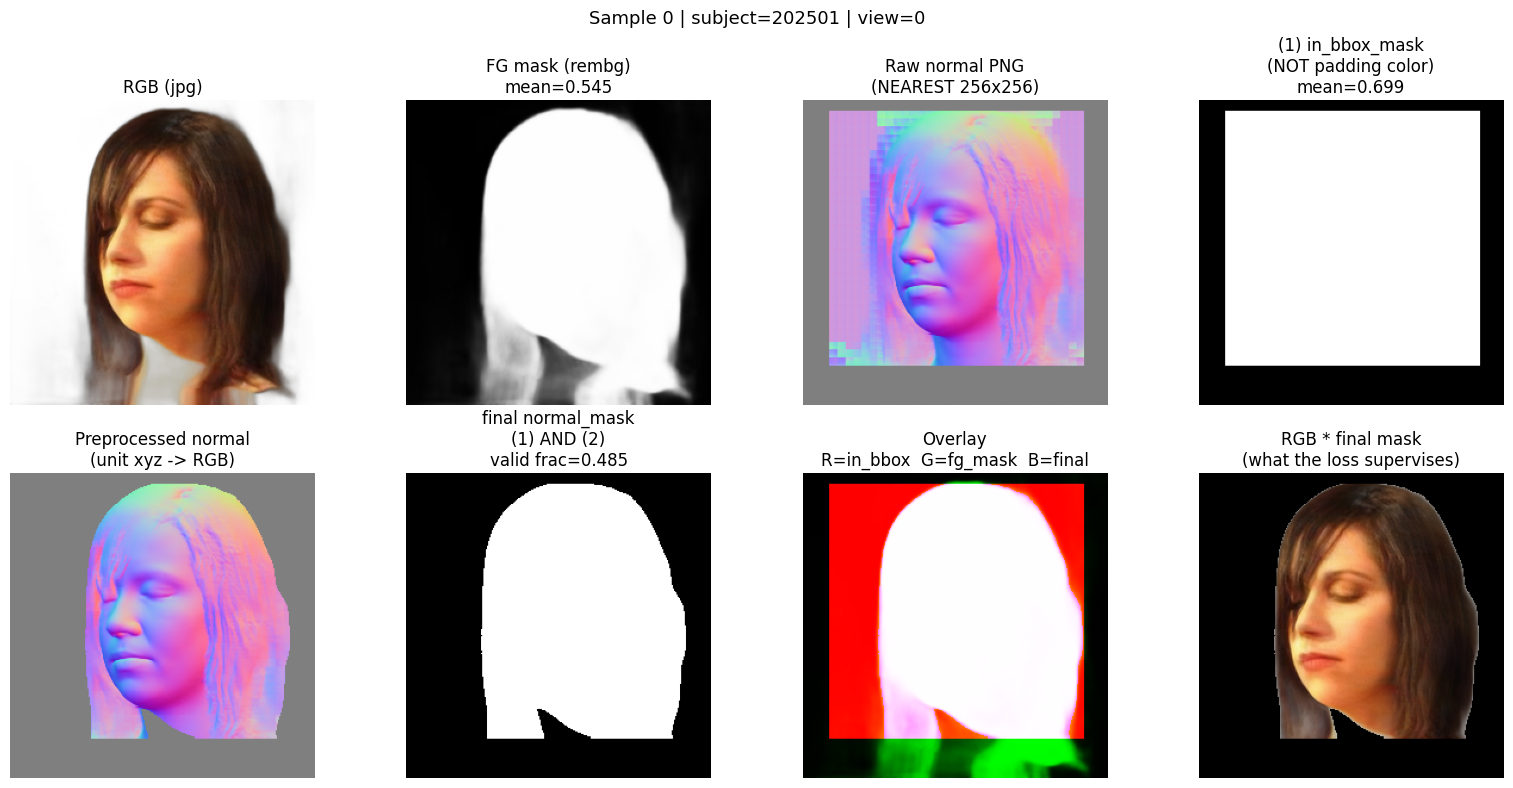

subject=202501
  raw corner TL: rgb=[0.498 0.498 0.498], mag=0.8626
  raw corner TR: rgb=[0.498 0.498 0.498], mag=0.8626
  raw corner BL: rgb=[0.498 0.498 0.498], mag=0.8626
  raw corner BR: rgb=[0.498 0.498 0.498], mag=0.8626
  detected padding color: rgb=[0.498 0.498 0.498]
  in_bbox_mask valid fraction:  0.6988  (after stage 1)
  fg_mask valid fraction:       0.5446
  final normal_mask valid frac: 0.4853  (after stage 1 AND 2)


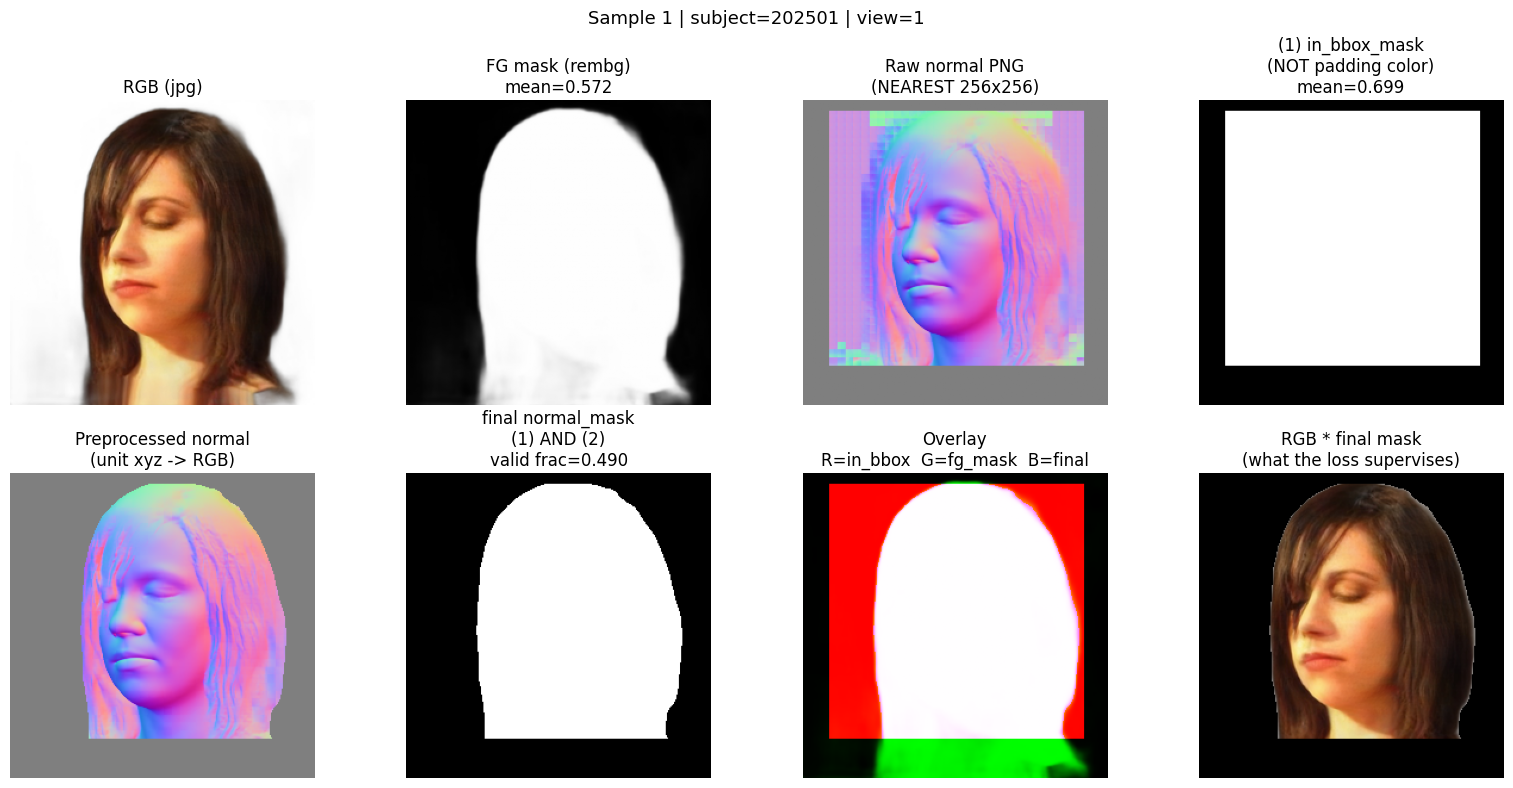

subject=202501
  raw corner TL: rgb=[0.498 0.498 0.498], mag=0.8626
  raw corner TR: rgb=[0.498 0.498 0.498], mag=0.8626
  raw corner BL: rgb=[0.498 0.498 0.498], mag=0.8626
  raw corner BR: rgb=[0.498 0.498 0.498], mag=0.8626
  detected padding color: rgb=[0.498 0.498 0.498]
  in_bbox_mask valid fraction:  0.6988  (after stage 1)
  fg_mask valid fraction:       0.5716
  final normal_mask valid frac: 0.4904  (after stage 1 AND 2)


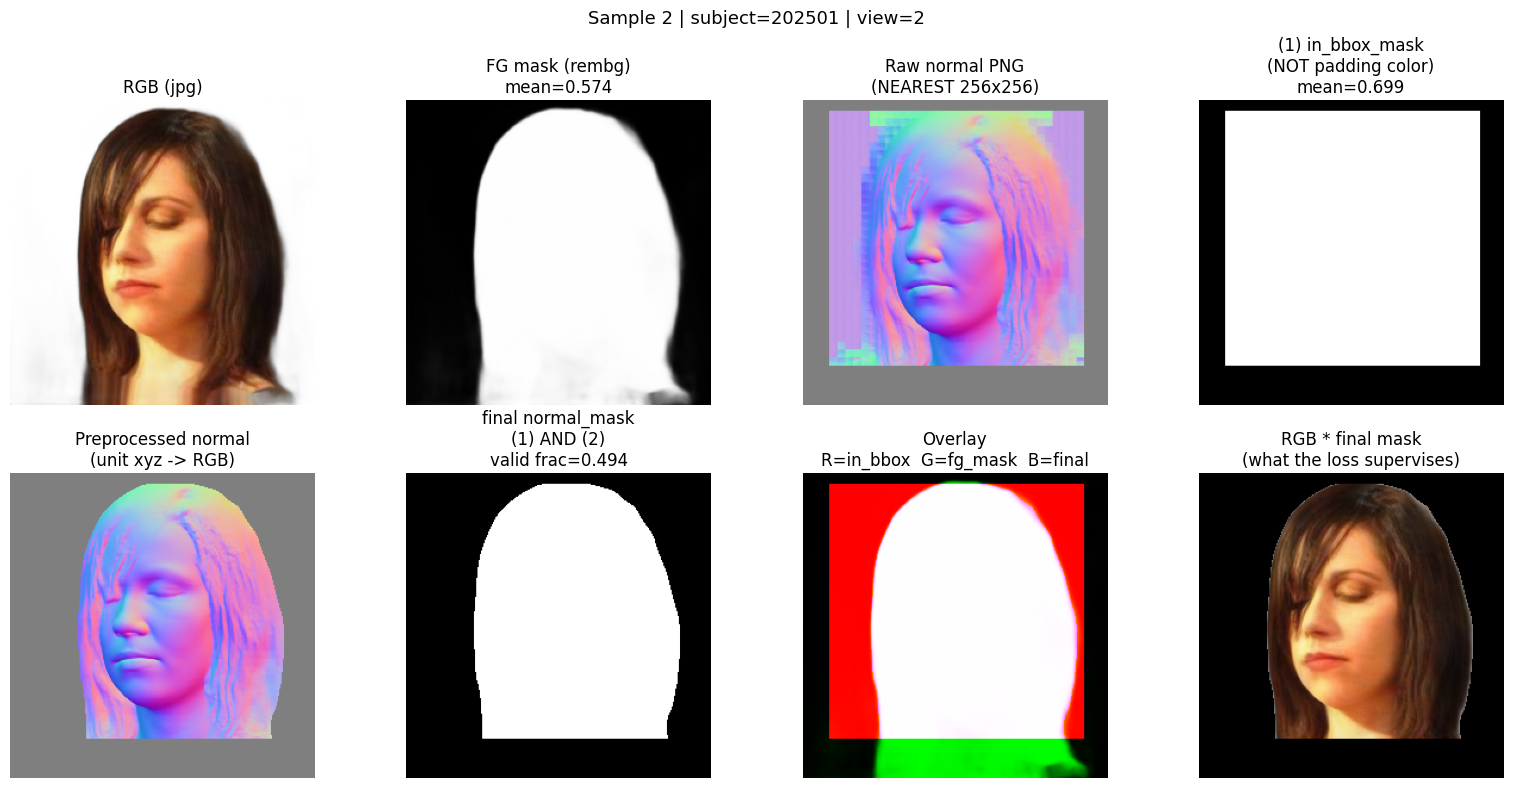

subject=202501
  raw corner TL: rgb=[0.498 0.498 0.498], mag=0.8626
  raw corner TR: rgb=[0.498 0.498 0.498], mag=0.8626
  raw corner BL: rgb=[0.498 0.498 0.498], mag=0.8626
  raw corner BR: rgb=[0.498 0.498 0.498], mag=0.8626
  detected padding color: rgb=[0.498 0.498 0.498]
  in_bbox_mask valid fraction:  0.6988  (after stage 1)
  fg_mask valid fraction:       0.5740
  final normal_mask valid frac: 0.4938  (after stage 1 AND 2)

--- From current dataloader batch (index 0) ---


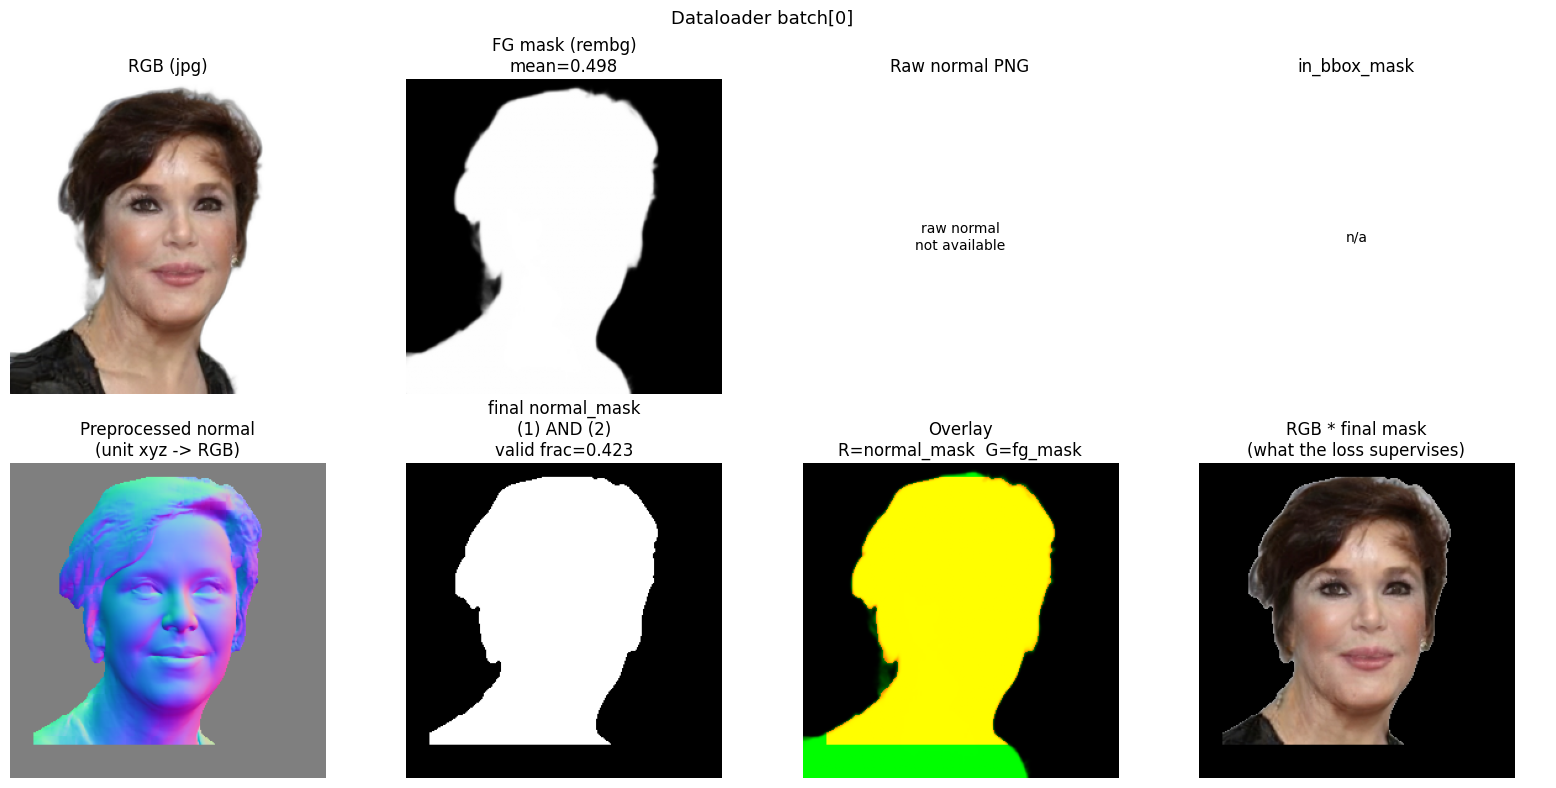

subject=202560
  fg_mask valid fraction:       0.4979
  final normal_mask valid frac: 0.4227  (after stage 1 AND 2)


In [ ]:
import matplotlib.pyplot as plt

def visualize_normal_and_mask(sample, title=None, show_raw=True):
    """Visualize the two-stage normal mask:
       (1) in_bbox_mask: pixels NOT matching the uncropping padding color
       (2) fg_mask:      rembg silhouette
       final normal_mask = (1) AND (2)
    """
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    rgb = sample["jpg"].permute(1, 2, 0).numpy()
    axes[0, 0].imshow(np.clip(rgb, 0, 1))
    axes[0, 0].set_title("RGB (jpg)")
    axes[0, 0].axis("off")

    fg_mask = sample["mask"][0].numpy()
    axes[0, 1].imshow(fg_mask, cmap="gray", vmin=0, vmax=1)
    axes[0, 1].set_title(f"FG mask (rembg)\nmean={fg_mask.mean():.3f}")
    axes[0, 1].axis("off")

    raw_normal = None
    bg_color = None
    in_bbox_mask = None
    if show_raw and "view_index" in sample:
        sub_path = os.path.join(TRAIN_ROOT, sample["subject_id"])
        view_id = f"{int(sample['view_index']):05d}"
        raw_normal_path = os.path.join(sub_path, "normals_uncropped", f"{view_id}.png")
        # NEAREST so corner pixels stay constant for accurate bg detection
        raw_normal = np.array(
            Image.open(raw_normal_path).convert("RGB").resize((256, 256), Image.NEAREST)
        ).astype(np.float32) / 255.0
        axes[0, 2].imshow(raw_normal)
        axes[0, 2].set_title("Raw normal PNG\n(NEAREST 256x256)")

        # Recompute the in-bbox (NOT padding) mask for visualization
        h, w = raw_normal.shape[:2]
        corner_arr = np.stack([
            raw_normal[0, 0], raw_normal[0, w - 1],
            raw_normal[h - 1, 0], raw_normal[h - 1, w - 1],
        ], axis=0)  # [4, 3]
        bg_color = np.median(corner_arr, axis=0)  # [3]
        diff = np.abs(raw_normal - bg_color[None, None, :]).max(axis=-1)
        in_bbox_mask = (diff > 0.02).astype(np.float32)
    else:
        axes[0, 2].text(0.5, 0.5, "raw normal\nnot available", ha="center", va="center")
        axes[0, 2].set_title("Raw normal PNG")
    axes[0, 2].axis("off")

    if in_bbox_mask is not None:
        axes[0, 3].imshow(in_bbox_mask, cmap="gray", vmin=0, vmax=1)
        axes[0, 3].set_title(f"(1) in_bbox_mask\n(NOT padding color)\nmean={in_bbox_mask.mean():.3f}")
    else:
        axes[0, 3].text(0.5, 0.5, "n/a", ha="center", va="center")
        axes[0, 3].set_title("in_bbox_mask")
    axes[0, 3].axis("off")

    normal_vis = _normal_to_rgb_vis(sample["normal"]).permute(1, 2, 0).numpy()
    axes[1, 0].imshow(normal_vis)
    axes[1, 0].set_title("Preprocessed normal\n(unit xyz -> RGB)")
    axes[1, 0].axis("off")

    normal_mask = sample["normal_mask"][0].numpy()
    axes[1, 1].imshow(normal_mask, cmap="gray", vmin=0, vmax=1)
    axes[1, 1].set_title(f"final normal_mask\n(1) AND (2)\nvalid frac={normal_mask.mean():.3f}")
    axes[1, 1].axis("off")

    # RGB overlay: R = in_bbox (stage 1), G = FG mask (stage 2), B = final intersection
    if in_bbox_mask is not None:
        overlay = np.stack([in_bbox_mask, fg_mask, normal_mask], axis=-1)
        axes[1, 2].imshow(overlay)
        axes[1, 2].set_title("Overlay\nR=in_bbox  G=fg_mask  B=final")
    else:
        overlay = np.stack([normal_mask, fg_mask, np.zeros_like(normal_mask)], axis=-1)
        axes[1, 2].imshow(overlay)
        axes[1, 2].set_title("Overlay\nR=normal_mask  G=fg_mask")
    axes[1, 2].axis("off")

    # RGB applied to mask: shows what the loss actually sees
    masked_rgb = np.clip(rgb, 0, 1) * normal_mask[..., None]
    axes[1, 3].imshow(masked_rgb)
    axes[1, 3].set_title("RGB * final mask\n(what the loss supervises)")
    axes[1, 3].axis("off")

    if title:
        fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f"subject={sample['subject_id']}")
    if raw_normal is not None:
        h, w = raw_normal.shape[:2]
        corners = {
            "TL": raw_normal[0, 0], "TR": raw_normal[0, w - 1],
            "BL": raw_normal[h - 1, 0], "BR": raw_normal[h - 1, w - 1],
        }
        for name, px in corners.items():
            print(f"  raw corner {name}: rgb={px.round(3)}, mag={np.linalg.norm(px):.4f}")
        print(f"  detected padding color: rgb={bg_color.round(3)}")
        print(f"  in_bbox_mask valid fraction:  {in_bbox_mask.mean():.4f}  (after stage 1)")
    print(f"  fg_mask valid fraction:       {fg_mask.mean():.4f}")
    print(f"  final normal_mask valid frac: {normal_mask.mean():.4f}  (after stage 1 AND 2)")


num_vis = min(3, len(train_dataset))
for i in range(num_vis):
    sample = dict(train_dataset[i])
    sample["view_index"] = train_dataset.samples[i]["view_index"]
    visualize_normal_and_mask(
        sample,
        title=f"Sample {i} | subject={sample['subject_id']} | view={sample['view_index']}",
    )

if "normal" in batch and "normal_mask" in batch:
    print("\n--- From current dataloader batch (index 0) ---")
    batch_sample = {k: (v[0] if torch.is_tensor(v) else v[0]) for k, v in batch.items()}
    visualize_normal_and_mask(batch_sample, title="Dataloader batch[0]", show_raw=False)

In [ ]:
# import os
# from PIL import Image
# from torch.utils.data import Dataset
# import numpy as np
# import torch
# from torchvision import transforms as T

# import os

# def preprocess_normal_for_cosine(normal_rgb, valid_eps=0.1):
#     """
#     Preprocess normal map for cosine similarity loss.

#     Args:
#         normal_rgb: [H, W, 3] or [3, H, W], values in [0, 1] (standard normal map: RGB = xyz)
#         valid_eps: pixels with magnitude < valid_eps in [0,1] space are invalid (e.g. black)

#     Returns:
#         normal: [3, H, W] L2-normalized, in [-1, 1] range
#         valid_mask: [1, H, W] float, 1 where valid, 0 where invalid
#     """
#     if isinstance(normal_rgb, np.ndarray):
#         normal = torch.from_numpy(normal_rgb).float()
#     else:
#         normal = normal_rgb.float()

#     if normal.ndim == 3 and normal.shape[-1] == 3:
#         normal = normal.permute(2, 0, 1)  # HWC -> CHW

#     # Valid region: pixels where magnitude in [0,1] space > eps (exclude black/invalid)
#     mag = normal.norm(dim=0, keepdim=True)
#     valid_mask = (mag.squeeze(0) > valid_eps).float().unsqueeze(0)

#     # RGB [0, 1] -> xyz [-1, 1]
#     normal = normal * 2.0 - 1.0

#     # L2 normalize per pixel (for cosine similarity)
#     norm = normal.norm(dim=0, keepdim=True).clamp(min=1e-8)
#     normal = normal / norm

#     return normal, valid_mask

# def preprocess_image(input_im):
#     '''
#     :param input_im (PIL Image).
#     :return input_im (H, W, 3) array in [0, 1].
#     '''
#     input_im = input_im.resize([256, 256], Image.Resampling.LANCZOS)
#     input_im = np.asarray(input_im, dtype=np.float32) / 255.0
#     # (H, W, 4) array in [0, 1].

#     # old method: thresholding background, very important
#     # input_im[input_im[:, :, -1] <= 0.9] = [1., 1., 1., 1.]

#     # new method: apply correct method of compositing to avoid sudden transitions / thresholding
#     # (smoothly transition foreground to white background based on alpha values)
#     if input_im.shape[-1] == 4:
#         alpha = input_im[:, :, 3:4]
#         white_im = np.ones_like(input_im)
#         input_im = alpha * input_im + (1.0 - alpha) * white_im

#     input_im = input_im[:, :, 0:3]
#     # (H, W, 3) array in [0, 1].

#     return input_im

# def _normal_to_rgb_vis(norm):
#     """Map unit normal field to RGB in [0,1] for visualization. norm: [B,3,H,W] or [3,H,W]. Returns [3,H,W]."""
#     if norm.dim() == 4:
#         norm = norm[0]
#     return torch.clamp((norm + 1) / 2, 0, 1)

# class Portrait4dDataset(Dataset):
#     def __init__(self, root_dir, transform=None, src_view_idx=9, skip_identity=True,
#                  load_normals=False, load_depth=False, subject_filter=None):
#         super().__init__()
#         self.root_dir = root_dir
#         self.transform = transform
#         self.src_view_idx = src_view_idx
#         self.skip_identity = skip_identity
#         self.load_normals = load_normals
#         self.load_depth = load_depth

#         self.subjects = [d for d in os.listdir(root_dir)
#                          if os.path.isdir(os.path.join(root_dir, d))]
#         if subject_filter is not None:
#             self.subjects = [s for s in self.subjects if s in subject_filter]
#         self.samples = []
#         skipped = 0

#         for sub in self.subjects:
#             sub_path = os.path.join(root_dir, sub)
#             poses_path = os.path.join(sub_path, 'poses.npy')
#             if not os.path.exists(poses_path):
#                 skipped += 1
#                 continue

#             views = sorted([
#                 f for f in os.listdir(sub_path)
#                 if os.path.isfile(os.path.join(sub_path, f))
#                 and os.path.splitext(f)[1].lower() in [".jpg", ".png"]
#                 and os.path.splitext(f)[0].isdigit()
#             ])
#             # views = sorted([f for f in os.listdir(sub_path)
#             #                if f.endswith('.jpg') and not f.startswith('src')])

#             for view_file in views:
#                 view_id = view_file.split('.')[0]
#                 view_index = int(view_id)
#                 if self.skip_identity and view_index == self.src_view_idx:
#                     continue

#                 mask_file = f"{view_id}_mask.png"
#                 normal_file = os.path.join("normals_uncropped", f"{view_id}.png")
#                 normal_path = os.path.join(sub_path, normal_file)
#                 depth_file = os.path.join("depth", f"{view_id}.npy")
#                 depth_path = os.path.join(sub_path, depth_file)

#                 has_mask = os.path.exists(os.path.join(sub_path, mask_file))
#                 has_normal = os.path.exists(normal_path) if self.load_normals else True
#                 has_depth = os.path.exists(depth_path) if self.load_depth else True

#                 if has_mask and has_normal and has_depth:
#                     self.samples.append({
#                         'sub_path': sub_path,
#                         'view_file': view_file,
#                         'mask_file': mask_file,
#                         'normal_file': normal_file,
#                         'depth_file': depth_file,
#                         'view_index': view_index,
#                     })

#         parts = []
#         if self.load_normals:
#             parts.append("normals")
#         if self.load_depth:
#             parts.append("depth")
#         extra_str = f" (with {', '.join(parts)})" if parts else ""
#         print(f"[Dataset] Loaded {len(self.samples)} samples{extra_str}, skipped {skipped} incomplete subjects")

#     def __len__(self):
#         return len(self.samples)

#     def __getitem__(self, idx):
#         sample = self.samples[idx]
#         sub_path = sample['sub_path']

#         src_path = os.path.join(sub_path, f"{self.src_view_idx:05d}.png")
#         src = Image.open(src_path).convert("RGBA")

#         img_path = os.path.join(sub_path, sample['view_file'])
#         image = Image.open(img_path).convert("RGBA")

#         mask_path = os.path.join(sub_path, sample['mask_file'])
#         mask = Image.open(mask_path).convert("L")

#         poses = np.load(os.path.join(sub_path, 'poses.npy'))
#         if poses.ndim == 2 and poses.shape[1] == 16:
#             poses = poses.reshape(-1, 4, 4)

#         delta_pose = compute_relative_pose(
#             poses[self.src_view_idx],
#             poses[sample['view_index']]
#         )
#         assert abs(delta_pose[1]) < 1.0, f"Yaw {delta_pose[1]} seems too large - check units!"
#         delta_pose = torch.from_numpy(delta_pose).float()

#         src = preprocess_image(src) # Returns [H, W, 3] numpy array
#         image = preprocess_image(image) # Returns [H, W, 3] numpy array

#         src = torch.from_numpy(src).permute(2, 0, 1).float()
#         image = torch.from_numpy(image).permute(2, 0, 1).float()

#         if self.transform:
#             src = self.transform(src)
#             image = self.transform(image)

#         mask_transform = T.Compose([T.Resize((256, 256)), T.ToTensor()])
#         mask = mask_transform(mask)

#         out = {
#             "jpg": image,
#             "hint": src,
#             "mask": mask,
#             "delta_pose": delta_pose,
#             "subject_id": os.path.basename(sub_path),
#             "txt": ""
#         }

#         if self.load_normals:
#             normal_path = os.path.join(sub_path, sample['normal_file'])
#             normal_img = Image.open(normal_path).convert("RGB")
#             normal_img = normal_img.resize((256, 256), Image.BILINEAR)
#             normal_np = np.array(normal_img).astype(np.float32) / 255.0
#             normal, normal_valid_mask = preprocess_normal_for_cosine(normal_np, valid_eps=0.1)
#             out["normal"] = normal
#             out["normal_mask"] = normal_valid_mask

#         if self.load_depth:
#             depth_path = os.path.join(sub_path, sample['depth_file'])
#             depth_np = np.load(depth_path).astype(np.float32)
#             if depth_np.ndim == 3:  # (H, W, 1) or (1, H, W) -> (H, W)
#                 depth_np = depth_np.squeeze()
#             # Sanitize BEFORE interpolation: bilinear weights spread NaN to neighbors
#             depth_np = np.nan_to_num(depth_np, nan=0.0, posinf=0.0, neginf=0.0)
#             depth_t = torch.from_numpy(depth_np).float().unsqueeze(0)  # [1, H, W]
#             depth_t = torch.nn.functional.interpolate(
#                 depth_t.unsqueeze(0), size=(256, 256),
#                 mode='bilinear', align_corners=False
#             ).squeeze(0)  # [1, H, W]
#             depth_t = torch.clamp(depth_t, min=0.0)  # ensure non-negative
#             valid = (depth_t > 1e-6) & (depth_t < 1e6)
#             depth_mask = valid.float()
#             out["depth"] = depth_t
#             out["depth_mask"] = depth_mask

#         return out

# from torchvision import transforms as T
# from torch.utils.data import Dataset, DataLoader

# transform = T.Compose([
#     T.Resize((256, 256))
# ])

# DATA_ROOT = "/content/drive/MyDrive/datasets/TOSS_Dataset/nersemble_v2"
# # dataset_name = "portrait4d_rembg_isnet"

# # train_subject_filter = [str(202510 + n) for n in range(11) if 202510 + n != 202514][:10]
# # test_subject_filter = []
# # print("train identities:", train_subject_filter)
# # print("test  identities:", test_subject_filter)

# train_dataset = Portrait4dDataset(root_dir=DATA_ROOT, src_view_idx=3, subject_filter=None, transform=transform)
# # test_dataset  = Portrait4dDataset(root_dir=DATA_ROOT, subject_filter=test_subject_filter,  transform=transform)

# dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)

# data_iter = iter(dataloader)
# batch = next(data_iter)
# print("Batch keys:", batch.keys())


# Portrait4d Dataset (Range)

In [ ]:
'''
카메라 뷰 제한용 코드

예를 들어, 정의된 set (5,7,9,11,13) 의 뷰만 batch에 넣음
적은 뷰로만 fitting시켜보기 위한 코드
'''
# import os
# from PIL import Image
# from torch.utils.data import Dataset
# import numpy as np
# import torch
# from torchvision import transforms as T

# import os

# def preprocess_normal_for_cosine(normal_rgb, valid_eps=0.1):
#     """
#     Preprocess normal map for cosine similarity loss.

#     Args:
#         normal_rgb: [H, W, 3] or [3, H, W], values in [0, 1] (standard normal map: RGB = xyz)
#         valid_eps: pixels with magnitude < valid_eps in [0,1] space are invalid (e.g. black)

#     Returns:
#         normal: [3, H, W] L2-normalized, in [-1, 1] range
#         valid_mask: [1, H, W] float, 1 where valid, 0 where invalid
#     """
#     if isinstance(normal_rgb, np.ndarray):
#         normal = torch.from_numpy(normal_rgb).float()
#     else:
#         normal = normal_rgb.float()

#     if normal.ndim == 3 and normal.shape[-1] == 3:
#         normal = normal.permute(2, 0, 1)  # HWC -> CHW

#     # Valid region: pixels where magnitude in [0,1] space > eps (exclude black/invalid)
#     mag = normal.norm(dim=0, keepdim=True)
#     valid_mask = (mag.squeeze(0) > valid_eps).float().unsqueeze(0)

#     # RGB [0, 1] -> xyz [-1, 1]
#     normal = normal * 2.0 - 1.0

#     # L2 normalize per pixel (for cosine similarity)
#     norm = normal.norm(dim=0, keepdim=True).clamp(min=1e-8)
#     normal = normal / norm

#     return normal, valid_mask

# def preprocess_image(input_im):
#     '''
#     :param input_im (PIL Image).
#     :return input_im (H, W, 3) array in [0, 1].
#     '''
#     input_im = input_im.resize([256, 256], Image.Resampling.LANCZOS)
#     input_im = np.asarray(input_im, dtype=np.float32) / 255.0
#     # (H, W, 4) array in [0, 1].

#     # old method: thresholding background, very important
#     # input_im[input_im[:, :, -1] <= 0.9] = [1., 1., 1., 1.]

#     # new method: apply correct method of compositing to avoid sudden transitions / thresholding
#     # (smoothly transition foreground to white background based on alpha values)
#     if input_im.shape[-1] == 4:
#         alpha = input_im[:, :, 3:4]
#         white_im = np.ones_like(input_im)
#         input_im = alpha * input_im + (1.0 - alpha) * white_im

#     input_im = input_im[:, :, 0:3]
#     # (H, W, 3) array in [0, 1].

#     return input_im

# class Portrait4dDataset(Dataset):
#     def __init__(
#         self,
#         root_dir,
#         transform=None,
#         src_view_idx=9,
#         skip_identity=True,
#         load_normals=False,
#         view_indices=None,
#         hint_filename=None,
#     ):
#         super().__init__()
#         self.root_dir = root_dir
#         self.transform = transform
#         self.src_view_idx = src_view_idx
#         self.skip_identity = skip_identity
#         self.load_normals = load_normals
#         self.view_indices = view_indices
#         self._view_indices_set = None if view_indices is None else frozenset(view_indices)
#         self.hint_filename = hint_filename

#         self.subjects = [d for d in os.listdir(root_dir)
#                         if os.path.isdir(os.path.join(root_dir, d))]
#         self.samples = []

#         skipped = 0
#         for sub in self.subjects:
#             sub_path = os.path.join(root_dir, sub)
#             poses_path = os.path.join(sub_path, 'poses.npy')

#             if not os.path.exists(poses_path):
#                 skipped += 1
#                 continue

#             views = sorted([
#                 f for f in os.listdir(sub_path)
#                 if (f.lower().endswith('.jpg') or f.lower().endswith('.png'))
#                 and f.split('.')[0].isdigit()
#             ])

#             for view_file in views:
#                 view_id = view_file.split('.')[0]
#                 view_index = int(view_id)

#                 if self._view_indices_set is not None and view_index not in self._view_indices_set:
#                     continue

#                 if self.skip_identity and view_index == self.src_view_idx:
#                     continue

#                 mask_file = f"{view_id}_mask.png"
#                 normal_file = os.path.join("normals_uncropped", f"{view_id}.png")
#                 normal_path = os.path.join(sub_path, normal_file)

#                 has_mask = os.path.exists(os.path.join(sub_path, mask_file))
#                 has_normal = os.path.exists(normal_path) if self.load_normals else True

#                 if has_mask and has_normal:
#                     self.samples.append({
#                         'sub_path': sub_path,
#                         'view_file': view_file,
#                         'mask_file': mask_file,
#                         'normal_file': normal_file,
#                         'view_index': view_index
#                     })

#         norm_str = " (with normals)" if self.load_normals else ""
#         print(f"[Dataset] Loaded {len(self.samples)} samples{norm_str}, skipped {skipped} incomplete subjects")

#     def __len__(self):
#         return len(self.samples)

#     def __getitem__(self, idx):
#         sample = self.samples[idx]
#         sub_path = sample['sub_path']

#         if self.hint_filename is None:
#             hint_path = os.path.join(sub_path, f"{self.src_view_idx:05d}.png")
#         else:
#             hint_path = os.path.join(sub_path, self.hint_filename)
#         src = Image.open(hint_path).convert("RGBA")

#         img_path = os.path.join(sub_path, sample['view_file'])
#         image = Image.open(img_path).convert("RGBA")

#         mask_path = os.path.join(sub_path, sample['mask_file'])
#         mask = Image.open(mask_path).convert("L")

#         poses = np.load(os.path.join(sub_path, 'poses.npy'))
#         if poses.ndim == 2 and poses.shape[1] == 16:
#             poses = poses.reshape(-1, 4, 4)

#         delta_pose = compute_relative_pose(
#             poses[self.src_view_idx],
#             poses[sample['view_index']]
#         )
#         assert abs(delta_pose[1]) < 1.0, f"Yaw {delta_pose[1]} seems too large - check units!"
#         delta_pose = torch.from_numpy(delta_pose).float()

#         src = preprocess_image(src) # Returns [H, W, 3] numpy array
#         image = preprocess_image(image) # Returns [H, W, 3] numpy array

#         src = torch.from_numpy(src).permute(2, 0, 1).float()
#         image = torch.from_numpy(image).permute(2, 0, 1).float()

#         if self.transform:
#             src = self.transform(src)
#             image = self.transform(image)

#         mask_transform = T.Compose([T.Resize((256, 256)), T.ToTensor()])
#         mask = mask_transform(mask)

#         out = {
#             "jpg": image,
#             "hint": src,
#             "mask": mask,
#             "delta_pose": delta_pose,
#             "subject_id": os.path.basename(sub_path),
#             "txt": ""
#         }

#         if self.load_normals:
#             normal_path = os.path.join(sub_path, sample['normal_file'])
#             normal_img = Image.open(normal_path).convert("RGB")
#             normal_img = normal_img.resize((256, 256), Image.BILINEAR)
#             normal_np = np.array(normal_img).astype(np.float32) / 255.0  # [H, W, 3]

#             normal, normal_valid_mask = preprocess_normal_for_cosine(normal_np, valid_eps=0.1)
#             out["normal"] = normal
#             out["normal_mask"] = normal_valid_mask  # valid region for geometry loss

#         return out

# from torchvision import transforms as T
# from torch.utils.data import Dataset, DataLoader

# transform = T.Compose([
#     T.Resize((256, 256)),
#     view_indices=(5,7,9,11,13)
# ])

# dataset_name = "portrait4d_rembg"
# dataset = Portrait4dDataset(
#     root_dir=f"/content/drive/MyDrive/datasets/TOSS_Dataset/portrait4d_rembg", transform=transform
# )

# dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0)

# data_iter = iter(dataloader)
# batch = next(data_iter)
# print("Batch keys:", batch.keys())

'\n카메라 뷰 제한용 코드\n\n예를 들어, 정의된 set (5,7,9,11,13) 의 뷰만 batch에 넣음\n적은 뷰로만 fitting시켜보기 위한 코드\n'

# Depth Visualization

In [ ]:
# import matplotlib.pyplot as plt
# import torch

# ds = Portrait4dDataset(root_dir=f"/content/drive/MyDrive/datasets/TOSS_Dataset/portrait4d_rembg", transform=transform)

# for i in [0, 10, 20]:
#     item = ds[i]
#     img = item["jpg"].permute(1, 2, 0).cpu().numpy()
#     depth = item["depth"][0].cpu()
#     depth_mask = item["depth_mask"][0].cpu()
#     seg_mask = item["mask"][0].cpu()

#     valid = depth_mask > 0.5
#     overlap = valid & (seg_mask > 0.5)

#     print(f"sample {i}")
#     print("depth shape:", depth.shape)
#     print("valid ratio:", valid.float().mean().item())
#     print("seg ratio:", (seg_mask > 0.5).float().mean().item())
#     if valid.any():
#         v = depth[valid]
#         print("depth min/max/mean:", v.min().item(), v.max().item(), v.mean().item())

#     fig, ax = plt.subplots(1, 4, figsize=(16, 4))
#     ax[0].imshow(img)
#     ax[0].set_title("RGB")
#     ax[1].imshow(depth.numpy(), cmap="viridis")
#     ax[1].set_title("Depth")
#     ax[2].imshow(depth_mask.numpy(), cmap="gray")
#     ax[2].set_title("Depth mask")
#     ax[3].imshow(overlap.numpy(), cmap="gray")
#     ax[3].set_title("Overlap")
#     for a in ax:
#         a.axis("off")
#     plt.show()

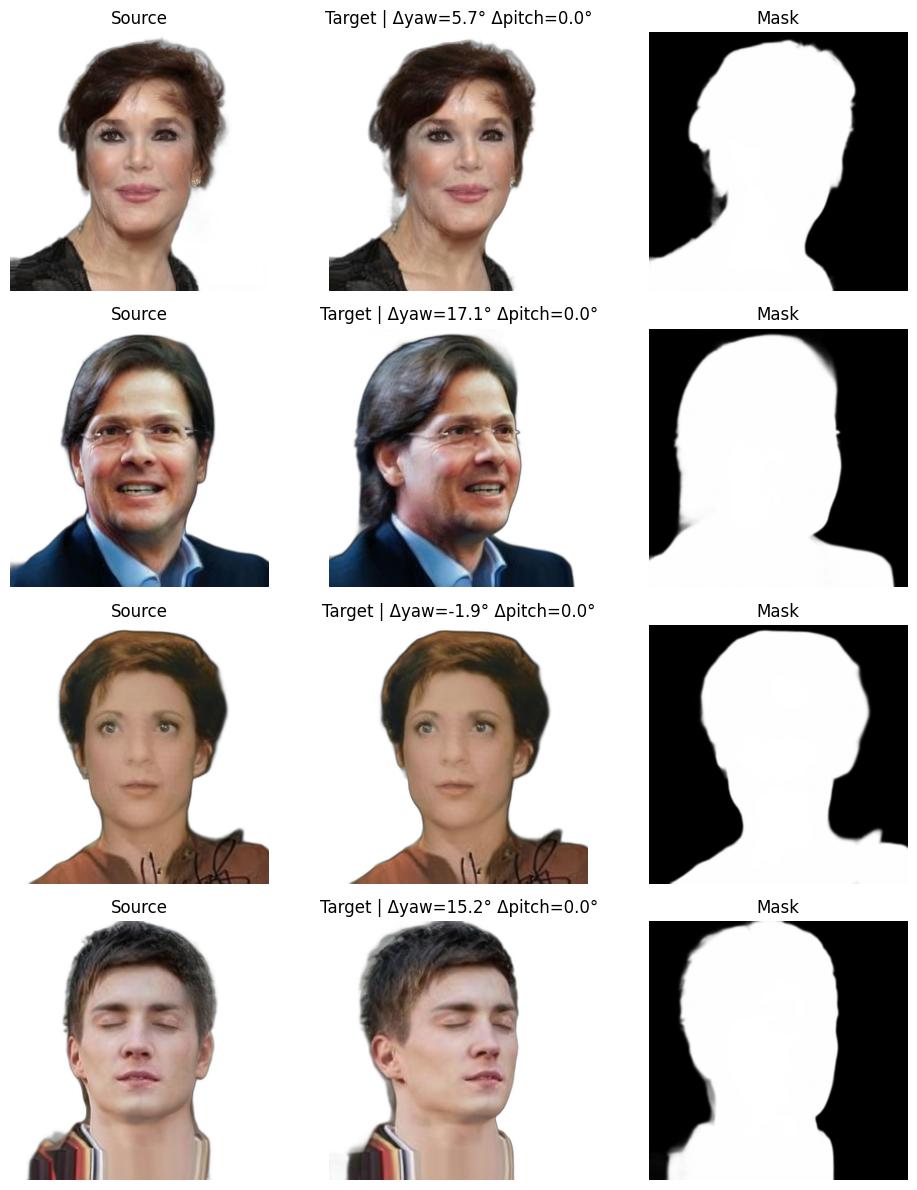

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_batch(batch, max_samples=4):
    n = min(max_samples, batch["jpg"].shape[0])
    fig, axes = plt.subplots(n, 3, figsize=(10, n * 3))
    if n == 1:
        axes = axes[None, :]

    for i in range(n):
        src = batch["hint"][i].permute(1, 2, 0).numpy().clip(0, 1)
        axes[i, 0].imshow(src)
        axes[i, 0].set_title("Source")
        axes[i, 0].axis("off")

        tgt = batch["jpg"][i].permute(1, 2, 0).numpy().clip(0, 1)
        dp = batch["delta_pose"][i].numpy()
        axes[i, 1].imshow(tgt)
        axes[i, 1].set_title(f"Target | Δyaw={np.degrees(dp[1]):.1f}° Δpitch={np.degrees(dp[0]):.1f}°")
        axes[i, 1].axis("off")

        mask = batch["mask"][i].squeeze().numpy()
        axes[i, 2].imshow(mask, cmap="gray")
        axes[i, 2].set_title("Mask")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

visualize_batch(batch)

# Training

In [ ]:
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint

checkpoint_cb = ModelCheckpoint(
    dirpath="/content/drive/MyDrive/checkpoints/toss_lora/",
    filename="toss-{step}",
    save_last=True,
    every_n_train_steps=500
)

trainer = pl.Trainer(
    max_steps=3000, # 1 step = 1 batch(4)
    accelerator="gpu",
    devices=1,
    callbacks=[checkpoint_cb],
    log_every_n_steps=10,
    gradient_clip_val=1.0,
    enable_checkpointing=True,
)

# Additional Config
model.learning_rate = 3e-4
model.sd_locked = True
model.first_stage_key = "jpg"
model.control_key = "hint"
model.cond_stage_key = "txt"

import torch.utils.checkpoint as cp
cp.checkpoint = lambda func, *args, **kwargs: func(*args)

trainer.fit(model, dataloader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/configuration_validator.py:108: PossibleUserWarning: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
  rank_zero_warn(
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/usr/local/lib/python3.12/dist-packages/pytorch_light

[OPT] LoRA param: base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_q.lora_A.default.weight, shape=torch.Size([16, 320])
[OPT] LoRA param: base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_q.lora_B.default.weight, shape=torch.Size([320, 16])
[OPT] LoRA param: base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_k.lora_A.default.weight, shape=torch.Size([16, 320])
[OPT] LoRA param: base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_k.lora_B.default.weight, shape=torch.Size([320, 16])
[OPT] LoRA param: base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_v.lora_A.default.weight, shape=torch.Size([16, 320])
[OPT] LoRA param: base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_v.lora_B.default.weight, shape=torch.Size([320, 16])
[OPT] LoRA param: base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_out.0.lora_A.default.weight, shape=torch.Size([16, 320])
[OPT] LoRA param: base_model.model.input_blocks.1.1

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 12 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

get_input raw control: torch.Size([4, 3, 256, 256])
Data shape for DDIM sampling is (1, 4, 32, 32), eta 0.0
Running DDIM Sampling with 20 timesteps


...


DDIM Sampler: 100%|██████████| 20/20 [00:01<00:00, 14.35it/s]


Data shape for DDIM sampling is (1, 4, 32, 32), eta 0.0
Running DDIM Sampling with 20 timesteps



DDIM Sampler: 100%|██████████| 20/20 [00:01<00:00, 14.47it/s]


[VIS] Logged multiview (+ normals) at step 2950
LOSS logged: total=0.6809
get_input raw control: torch.Size([4, 3, 256, 256])
LOSS logged: total=0.0369
get_input raw control: torch.Size([4, 3, 256, 256])
LOSS logged: total=0.4985
get_input raw control: torch.Size([4, 3, 256, 256])
LOSS logged: total=0.6615
get_input raw control: torch.Size([4, 3, 256, 256])
LOSS logged: total=0.2594
get_input raw control: torch.Size([4, 3, 256, 256])
LOSS logged: total=0.2855
get_input raw control: torch.Size([4, 3, 256, 256])
LOSS logged: total=0.0572
get_input raw control: torch.Size([4, 3, 256, 256])
LOSS logged: total=0.0416
get_input raw control: torch.Size([4, 3, 256, 256])
LOSS logged: total=0.1533
get_input raw control: torch.Size([4, 3, 256, 256])
LOSS logged: total=0.0759
get_input raw control: torch.Size([4, 3, 256, 256])
LOSS logged: total=0.0898
get_input raw control: torch.Size([4, 3, 256, 256])
LOSS logged: total=0.4679
get_input raw control: torch.Size([4, 3, 256, 256])
LOSS logged: tot

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=3000` reached.


In [ ]:
from google.colab import runtime
runtime.unassign()

# TOSS_LORA Inference

In [ ]:
%cd /content/TOSS-Human-Novel-Views

/content/TOSS-Human-Novel-Views


In [ ]:
"""
TOSS inference API for notebooks — same sampling pipeline as app.py (no Gradio, no CLI).

Example:
    from inference import TossInference
    runner = TossInference(resume_path="ckpt/toss.ckpt")
    out = runner.generate("input.png", prompt="a red shoe", dy=-90)
    out = runner.generate(pil_image, prompt="", dx=0, dy=0, dz=0)
"""
from __future__ import annotations

from pathlib import Path
from types import SimpleNamespace
from typing import Union

import numpy as np
import torch
from einops import rearrange
from omegaconf import OmegaConf
from PIL import Image
from pytorch_lightning import seed_everything
from torchvision import transforms

from ldm.models.diffusion.ddim import DDIMSampler
from ldm.util import instantiate_from_config

from cldm.toss import TOSS
from cldm.model import load_state_dict



from app import get_T_from_relative, preprocess_image, sample_model

def load_model(device, _hparams, sd_locked, only_mid_control, cfgs):
    import os
    os.environ["WANDB_MODE"] = "disabled"
    model = instantiate_from_config(cfgs.model)

    # Load the state dict
    state_dict = torch.load("/content/drive/MyDrive/checkpoints/toss.ckpt", map_location="cpu", weights_only=False)["state_dict"]

    # --- FIX START ---
    # Remove the problematic key if it exists
    key_to_remove = "cond_stage_model.transformer.text_model.embeddings.position_ids"
    if key_to_remove in state_dict:
        print(f"Removing {key_to_remove} from state_dict to match model structure.")
        del state_dict[key_to_remove]
    # --- FIX END ---

    model.load_state_dict(state_dict, strict=False) # Adding strict=False is a safe backup

    trained_ckpt = torch.load("/content/drive/MyDrive/checkpoints/toss_lora/toss-step=3000-v6.ckpt", map_location="cpu", weights_only=False)

    lora_keys = [k for k in trained_ckpt["state_dict"].keys() if "lora" in k.lower()]
    print(f"Found {len(lora_keys)} LoRA keys in checkpoint:")
    for k in lora_keys:
        print(f"  {k}: {trained_ckpt['state_dict'][k].abs().mean().item():.6f}")

    # This will inject your LoRA weights and your trained PoseNet
    m, u = model.load_state_dict(trained_ckpt["state_dict"], strict=False)

    print()

    for n, p in model.named_parameters():
      if "lora" in n.lower() or ".out." in n.lower():
          print(n, p.abs().mean().item())

    print("Missing:", m)
    print("Unexpected keys (should be empty):", u)

    # reweight noise scheduler
    if _hparams.register_scheduler:
        model.register_schedule(given_betas=None, beta_schedule="linear", timesteps=1000, linear_start=0.00085, linear_end=0.016)

    model.learning_rate = _hparams.lr
    model.sd_locked = sd_locked
    model.only_mid_control = only_mid_control
    model = model.to(device)
    model.eval()
    return model

ImageInput = Union[str, Path, Image.Image, np.ndarray]


def _to_pil_rgba(image: ImageInput) -> Image.Image:
    if isinstance(image, (str, Path)):
        return Image.open(image).convert("RGBA")
    if isinstance(image, Image.Image):
        return image.convert("RGBA")
    if isinstance(image, np.ndarray):
        arr = image
        if arr.dtype != np.uint8:
            arr = np.clip(arr, 0.0, 1.0)
            if arr.max() <= 1.0:
                arr = (arr * 255.0).astype(np.uint8)
            else:
                arr = arr.astype(np.uint8)
        if arr.ndim == 2:
            raise ValueError("grayscale numpy arrays are not supported; use RGB/RGBA")
        if arr.shape[-1] == 4:
            return Image.fromarray(arr, mode="RGBA")
        if arr.shape[-1] == 3:
            return Image.fromarray(arr, mode="RGB").convert("RGBA")
        raise ValueError(f"expected HxWx3 or HxWx4 array, got shape {arr.shape}")
    raise TypeError(f"unsupported image type: {type(image)}")

class TossInference:
    """Load TOSS once, then call ``generate`` with varying inputs (notebook-friendly)."""

    def __init__(
        self,
        model_cfg: str | Path = "models/toss_vae.yaml",
        resume_path: str | Path = "/content/drive/MyDrive/checkpoints/toss.ckpt",
        *,
        device: torch.device | str | None = None,
        gpu: int = 0,
        register_scheduler: bool = False,
        lr: float = 1e-4,
        seed: int = 40,
        sd_locked: bool = True,
        only_mid_control: bool = False,
        use_ema_scope: bool = True,
        pose_enc: str = "freq",
        h: int = 256,
        w: int = 256,
    ):
        """
        Args:
            model_cfg: YAML defining the model (e.g. ``models/toss_vae.yaml``).
            resume_path: Checkpoint with ``state_dict`` (e.g. ``ckpt/toss.ckpt``).
            device: Explicit device; if None, uses ``cuda:{gpu}`` when available.
            gpu: CUDA index when ``device`` is None.
            register_scheduler: Passed through to ``load_model`` (same as training flag).
            lr: Required by ``load_model``; not used during inference.
            seed: Fixed at init; call ``set_seed`` to change between runs.
            use_ema_scope / pose_enc / h / w: Defaults for ``generate`` (overridable per call).
        """
        seed_everything(seed, workers=True)
        if device is None:
            self.device = torch.device(
                f"cuda:{gpu}" if torch.cuda.is_available() else "cpu"
            )
        else:
            self.device = torch.device(device)

        hparams = SimpleNamespace(
            resume_path=str(resume_path),
            register_scheduler=register_scheduler,
            lr=lr,
        )
        cfgs = OmegaConf.load(str(model_cfg))
        self.model = load_model(
            self.device, hparams, sd_locked, only_mid_control, cfgs
        )

        trainable = [n for n, p in self.model.named_parameters() if p.requires_grad]
        print("Trainable parameters:", len(trainable))
        for n in trainable:
            print(n)

        self.sampler = DDIMSampler(self.model)

        self._default_use_ema_scope = use_ema_scope
        self._default_pose_enc = pose_enc
        self._default_h = h
        self._default_w = w

    def set_seed(self, seed: int) -> None:
        """Call between ``generate`` runs for reproducible DDIM noise."""
        seed_everything(seed, workers=True)

    @torch.no_grad()
    def generate(
        self,
        image: ImageInput,
        prompt: str = "",
        dx: float = 0.0,
        dy: float = 0.0,
        dz: float = 0.0,
        *,
        pose_enc: str | None = None,
        h: int | None = None,
        w: int | None = None,
        precision: str = "fp32",
        n_samples: int = 1,
        use_ema_scope: bool | None = None,
        ddim_steps: int = 100,
        ddim_eta: float = 1.0,
        prompt_scale: float = 5.0,
        img_scale: float = 3.0,
        img_ucg: float = 0.05,
    ) -> Image.Image:
        """
        Novel view for one image (same logic as ``app.generate_loop_views`` / ``sample_model``).

        Args:
            image: Path, ``PIL.Image``, or ``HxWx3`` / ``HxWx4`` numpy array (float or uint8).
            prompt: Text conditioning (empty string allowed).
            dx, dy, dz: Relative pose in degrees / distance (see ``app.get_T_from_relative``).
        """
        h = self._default_h if h is None else h
        w = self._default_w if w is None else w
        pose_enc = self._default_pose_enc if pose_enc is None else pose_enc
        if use_ema_scope is None:
            use_ema_scope = self._default_use_ema_scope

        cond_im_pil = _to_pil_rgba(image)
        cond_im = preprocess_image(cond_im_pil)
        cond_im = transforms.ToTensor()(cond_im).unsqueeze(0).to(self.device)
        cond_im = transforms.functional.resize(cond_im, [h, w])

        T = get_T_from_relative(dx, dy, dz, pose_enc)
        x_samples = sample_model(
            cond_im,
            self.model,
            self.sampler,
            precision=precision,
            h=h,
            w=w,
            ddim_steps=ddim_steps,
            n_samples=n_samples,
            prompt_scale=prompt_scale,
            img_scale=img_scale,
            ddim_eta=ddim_eta,
            T=T,
            use_ema_scope=use_ema_scope,
            prompt=prompt,
            img_ucg=img_ucg,
        )
        assert x_samples.shape[0] == 1
        out = x_samples[0].cpu().numpy()
        out = 255.0 * rearrange(out, "c h w -> h w c")
        return Image.fromarray(out.astype(np.uint8))

/usr/local/lib/python3.12/dist-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/distributed.py:258: LightningDeprecationWarning: `pytorch_lightning.utilities.distributed.rank_zero_only` has been deprecated in v1.8.1 and will be removed in v2.0.0. You can import it from `pytorch_lightning.utilities` instead.
  rank_zero_deprecation(


logging improved.


INFO:lightning_fabric.utilities.seed:Global seed set to 40


In [ ]:
toss = TossInference()

INFO:lightning_fabric.utilities.seed:Global seed set to 40


[PATCH] Disabled gradient checkpointing in ldm_util.checkpoint
TossLoraModule: Running in eps-prediction mode
Setting up MemoryEfficientCrossAttention. Query dim is 320, context_dim is None and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 320, context_dim is 768 and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 320, context_dim is None and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 320, context_dim is 768 and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 640, context_dim is None and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 640, context_dim is 768 and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 640, context_dim is None and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 640, context_dim is 768 and using 8 heads.
Setting up MemoryEfficientCrossAttention. Query dim is 1280, context_dim is None and using 8 heads.
Se

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


[INIT] Unfreezing pose_net param: base_model.model.pose_net.0.weight, shape=torch.Size([320, 51])
[INIT] Unfreezing pose_net param: base_model.model.pose_net.0.bias, shape=torch.Size([320])
[INIT] Unfreezing pose_net param: base_model.model.pose_net.2.weight, shape=torch.Size([320, 320])
[INIT] Unfreezing pose_net param: base_model.model.pose_net.2.bias, shape=torch.Size([320])
[INIT] Unfroze 4 pose_net parameters
[INIT] Unfroze vae_proj parameters
[INIT] Enabled requires_grad for 128 LoRA parameters
  -> base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_q.lora_A.default.weight: shape=torch.Size([16, 320]), requires_grad=True
  -> base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_q.lora_B.default.weight: shape=torch.Size([320, 16]), requires_grad=True
  -> base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to_k.lora_A.default.weight: shape=torch.Size([16, 320]), requires_grad=True
  -> base_model.model.input_blocks.1.1.transformer_blocks.0.attn1.to

POSE_ENC: freq
Data shape for DDIM sampling is (1, 4, 32, 32), eta 1.0
Running DDIM Sampling with 100 timesteps


DDIM Sampler: 100%|██████████| 100/100 [00:06<00:00, 16.26it/s]


torch.Size([1, 4, 32, 32])
POSE_ENC: freq
Data shape for DDIM sampling is (1, 4, 32, 32), eta 1.0
Running DDIM Sampling with 100 timesteps


DDIM Sampler: 100%|██████████| 100/100 [00:06<00:00, 16.41it/s]


torch.Size([1, 4, 32, 32])
POSE_ENC: freq
Data shape for DDIM sampling is (1, 4, 32, 32), eta 1.0
Running DDIM Sampling with 100 timesteps


DDIM Sampler: 100%|██████████| 100/100 [00:06<00:00, 16.44it/s]


torch.Size([1, 4, 32, 32])
POSE_ENC: freq
Data shape for DDIM sampling is (1, 4, 32, 32), eta 1.0
Running DDIM Sampling with 100 timesteps


DDIM Sampler: 100%|██████████| 100/100 [00:06<00:00, 16.52it/s]


torch.Size([1, 4, 32, 32])


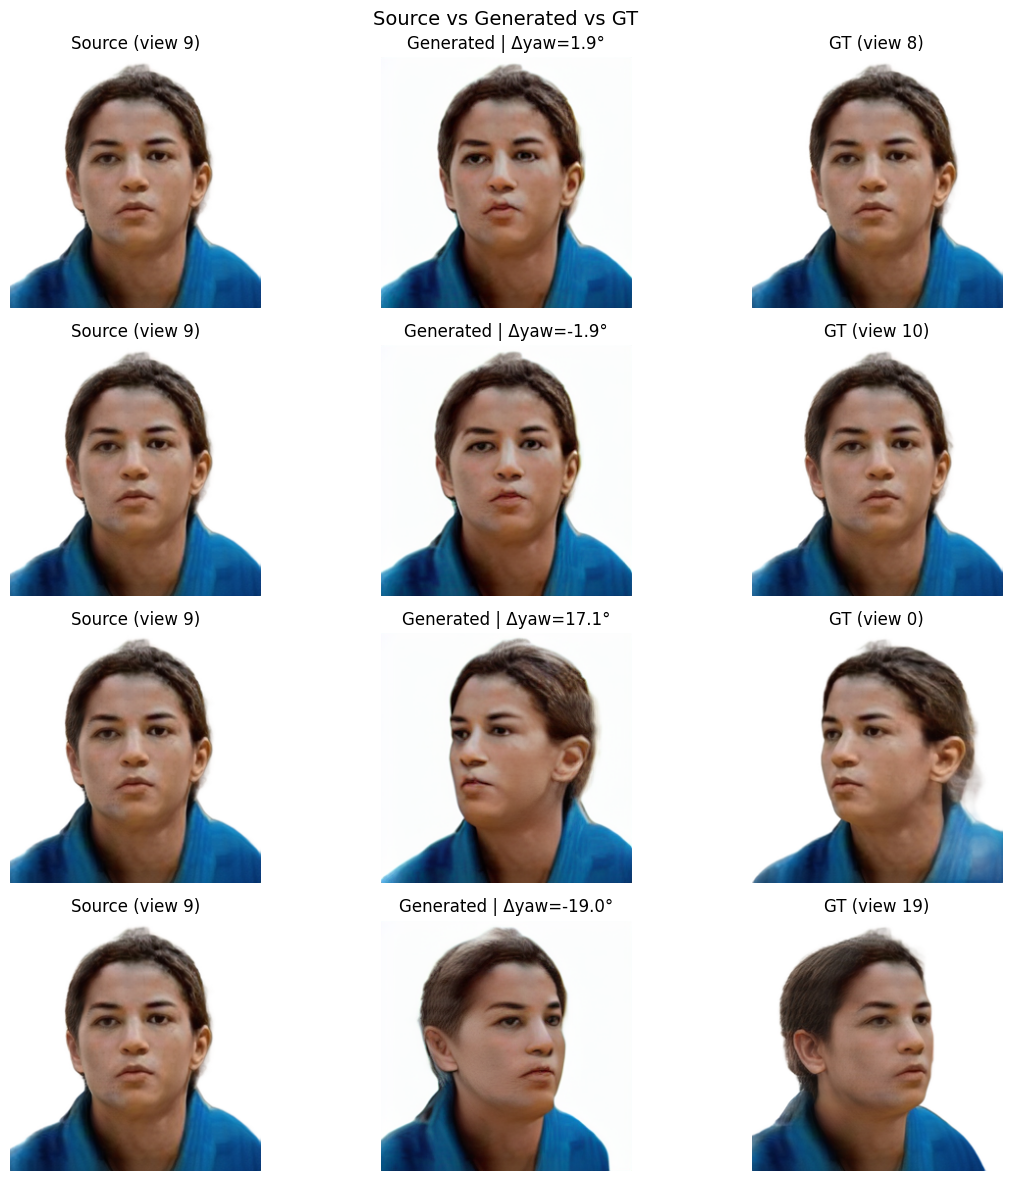

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math
import torch
from PIL import Image

sub_path = "/content/drive/MyDrive/datasets/TOSS_Dataset/portrait4d_rembg_isnet_v2/202575"
poses = np.load(f"{sub_path}/poses.npy").reshape(-1, 4, 4)

src_view_idx = 9
test_views = [8, 10, 0, 19]  # 가까운 2개, 먼 2개

src_img = Image.open(f"{sub_path}/{src_view_idx:05d}.png").convert("RGBA")

fig, axes = plt.subplots(len(test_views), 3, figsize=(12, len(test_views) * 3))
fig.suptitle("Source vs Generated vs GT", fontsize=14)

for row, view_idx in enumerate(test_views):
    # delta yaw 계산
    delta = compute_relative_pose(poses[src_view_idx], poses[view_idx])
    delta_yaw_deg = np.degrees(delta[1])

    # GT 이미지
    gt_img = Image.open(f"{sub_path}/{view_idx:05d}.png").convert("RGBA")
    gt_np = preprocess_image(gt_img)

    # Generate
    with torch.no_grad():
        gen_img = toss.generate(
            image=src_img,
            prompt="",
            dy=delta_yaw_deg,
        )

    # Source
    src_np = preprocess_image(src_img)
    axes[row, 0].imshow(src_np[:, :, :3])
    axes[row, 0].set_title(f"Source (view {src_view_idx})")
    axes[row, 0].axis("off")

    # Generated
    axes[row, 1].imshow(gen_img)
    axes[row, 1].set_title(f"Generated | Δyaw={delta_yaw_deg:.1f}°")
    axes[row, 1].axis("off")

    # GT
    axes[row, 2].imshow(gt_np[:, :, :3])
    axes[row, 2].set_title(f"GT (view {view_idx})")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import torch
from PIL import Image

def compute_psnr(pred, target, data_range=1.0, eps=1e-10):
    """pred, target: float arrays in [0, 1], shape (H, W, 3)."""
    pred = np.asarray(pred, dtype=np.float32)
    target = np.asarray(target, dtype=np.float32)
    mse = float(np.mean((pred - target) ** 2))
    if mse <= eps:
        return float("inf")
    return float(20.0 * np.log10(data_range / np.sqrt(mse)))

src_view_idx = 9
test_views = [8, 10, 0, 19]

per_view_psnr = {v: [] for v in test_views}
per_subject_psnr = {s: [] for s in test_subject_filter}
all_psnr = []

for sub in test_subject_filter:
    sub_path = f"{DATA_ROOT}/{sub}"
    poses = np.load(f"{sub_path}/poses.npy").reshape(-1, 4, 4)
    src_img = Image.open(f"{sub_path}/{src_view_idx:05d}.png").convert("RGBA")

    for view_idx in test_views:
        delta = compute_relative_pose(poses[src_view_idx], poses[view_idx])
        delta_yaw_deg = float(np.degrees(delta[1]))

        with torch.no_grad():
            gen_pil = toss.generate(image=src_img, prompt="", dy=delta_yaw_deg)

        gt_pil = Image.open(f"{sub_path}/{view_idx:05d}.png").convert("RGBA")
        gt_np  = preprocess_image(gt_pil)
        gen_np = np.asarray(gen_pil, dtype=np.float32) / 255.0

        psnr = compute_psnr(gen_np, gt_np, data_range=1.0)
        per_view_psnr[view_idx].append(psnr)
        per_subject_psnr[sub].append(psnr)
        all_psnr.append(psnr)
        print(f"  subject {sub}, view {view_idx:02d}, dyaw={delta_yaw_deg:+.1f}°: PSNR = {psnr:.3f} dB")

print("\n=== Per-view mean PSNR ===")
for v in test_views:
    print(f"  view {v:02d}: {np.mean(per_view_psnr[v]):.3f} dB (n={len(per_view_psnr[v])})")

print("\n=== Per-subject mean PSNR ===")
for s in test_subject_filter:
    if per_subject_psnr[s]:
        print(f"  {s}: {np.mean(per_subject_psnr[s]):.3f} dB")

print(f"\n=== Overall mean PSNR: {np.mean(all_psnr):.3f} dB ===")

POSE_ENC: freq
Data shape for DDIM sampling is (1, 4, 32, 32), eta 1.0
Running DDIM Sampling with 100 timesteps


DDIM Sampler: 100%|██████████| 100/100 [00:06<00:00, 16.11it/s]


torch.Size([1, 4, 32, 32])
  subject 202593, view 08, dyaw=+1.9°: PSNR = 23.546 dB
POSE_ENC: freq
Data shape for DDIM sampling is (1, 4, 32, 32), eta 1.0
Running DDIM Sampling with 100 timesteps


DDIM Sampler: 100%|██████████| 100/100 [00:06<00:00, 16.34it/s]


torch.Size([1, 4, 32, 32])
  subject 202593, view 10, dyaw=-1.9°: PSNR = 20.679 dB
POSE_ENC: freq
Data shape for DDIM sampling is (1, 4, 32, 32), eta 1.0
Running DDIM Sampling with 100 timesteps


...

torch.Size([1, 4, 32, 32])
  subject 202543, view 10, dyaw=-1.9°: PSNR = 23.950 dB
POSE_ENC: freq
Data shape for DDIM sampling is (1, 4, 32, 32), eta 1.0
Running DDIM Sampling with 100 timesteps


DDIM Sampler: 100%|██████████| 100/100 [00:06<00:00, 16.36it/s]


torch.Size([1, 4, 32, 32])
  subject 202543, view 00, dyaw=+17.1°: PSNR = 14.648 dB
POSE_ENC: freq
Data shape for DDIM sampling is (1, 4, 32, 32), eta 1.0
Running DDIM Sampling with 100 timesteps


DDIM Sampler: 100%|██████████| 100/100 [00:06<00:00, 16.15it/s]


torch.Size([1, 4, 32, 32])
  subject 202543, view 19, dyaw=-19.0°: PSNR = 17.283 dB

=== Per-view mean PSNR ===
  view 08: 24.507 dB (n=10)
  view 10: 24.528 dB (n=10)
  view 00: 18.589 dB (n=10)
  view 19: 18.320 dB (n=10)

=== Per-subject mean PSNR ===
  202593: 19.427 dB
  202583: 24.294 dB
  202538: 24.761 dB
  202581: 22.209 dB
  202562: 19.689 dB
  202589: 20.280 dB
  202598: 20.787 dB
  202550: 23.064 dB
  202539: 20.105 dB
  202543: 20.243 dB

=== Overall mean PSNR: 21.486 dB ===


POSE_ENC: freq
Data shape for DDIM sampling is (1, 4, 32, 32), eta 1.0
Running DDIM Sampling with 100 timesteps


DDIM Sampler: 100%|██████████| 100/100 [00:11<00:00,  8.73it/s]


torch.Size([1, 4, 32, 32])


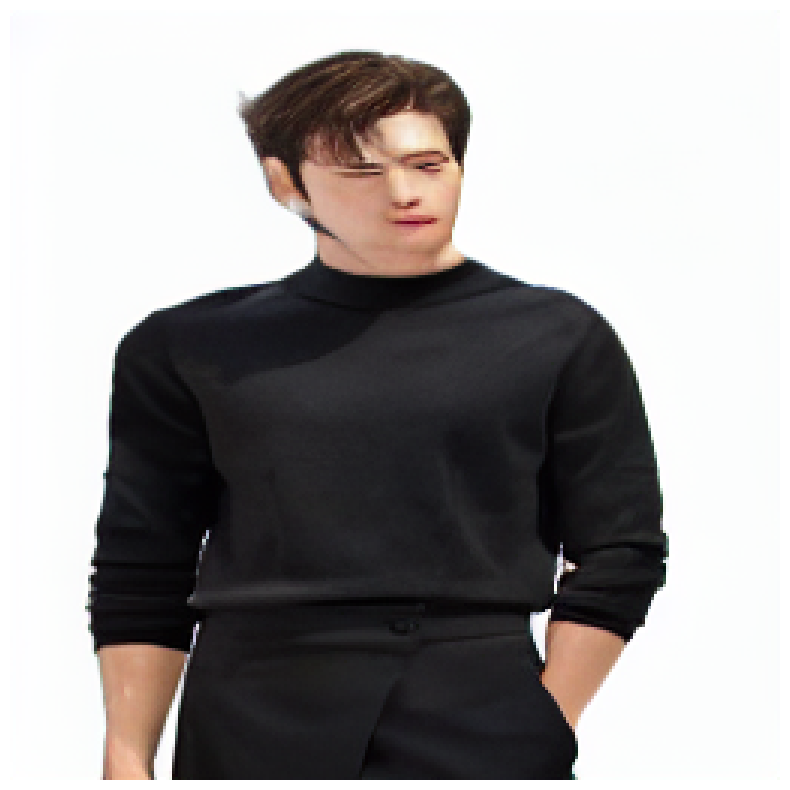

In [ ]:
img_name = "man1.png"
src_img = Image.open(f"{img_name}").convert("RGBA")

image = toss.generate(
    image=src_img,
    prompt="",
    dy=-10.0,
)

import matplotlib.pyplot as plt

# 1. Take the first image in the batch: [3, H, W]
# 2. Permute dimensions to: [H, W, 3]
# img_to_show = out[0].permute(1, 2, 0).numpy()

plt.tight_layout()
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('off') # Hide the x/y coordinates
plt.show()

# Depth Check

(802, 550)
0.0 1.674344


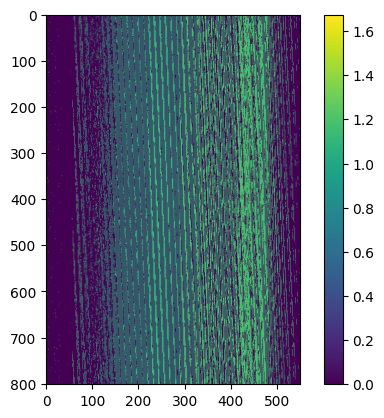

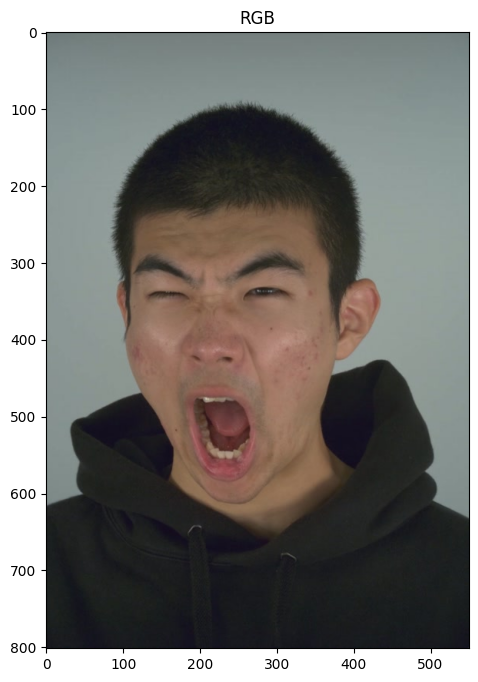

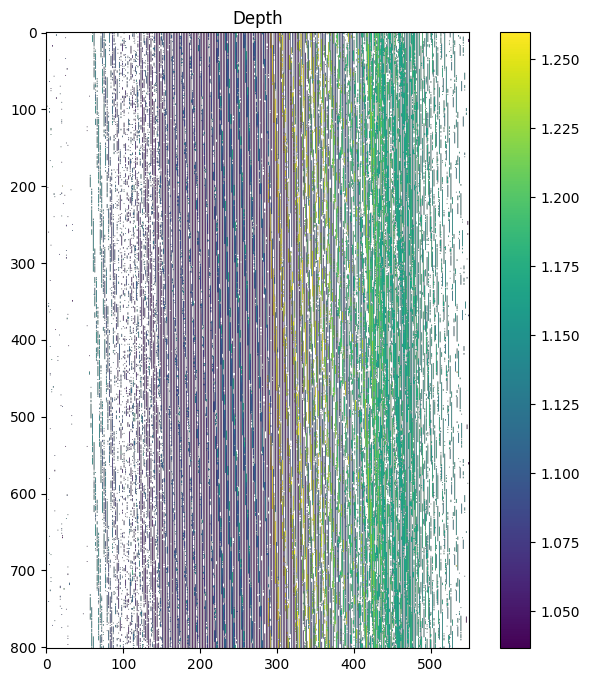

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def read_colmap_depth(path):
    with open(path, "rb") as f:

        header = b""
        num_delim = 0

        while num_delim < 3:
            c = f.read(1)
            header += c

            if c == b"&":
                num_delim += 1

        width, height, channels = map(
            int,
            header.decode("ascii").split("&")[:3]
        )

        data = np.fromfile(f, dtype=np.float32)

    depth = data.reshape(
        (height, width, channels),
        order="F"
    )

    return depth[:, :, 0]


depth = read_colmap_depth(
    "/content/220700191.png.geometric.bin"
)

print(depth.shape)
print(depth.min(), depth.max())

plt.imshow(depth)
plt.colorbar()
plt.show()

import matplotlib.pyplot as plt
from PIL import Image

img = Image.open("220700191.png")

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.title("RGB")
plt.show()

plt.figure(figsize=(8,8))
vis = depth.copy()
vis[vis <= 0] = float("nan")
plt.imshow(vis, vmin=np.nanpercentile(vis, 2), vmax=np.nanpercentile(vis, 98))
plt.colorbar()
plt.title("Depth")
plt.show()

(802, 550)
0.0 12.069331


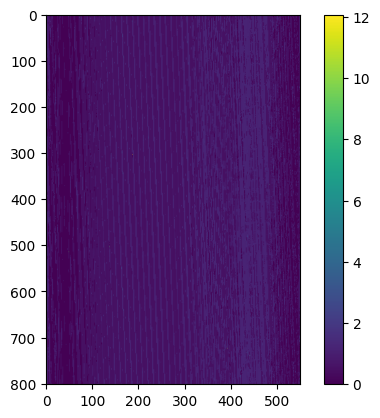

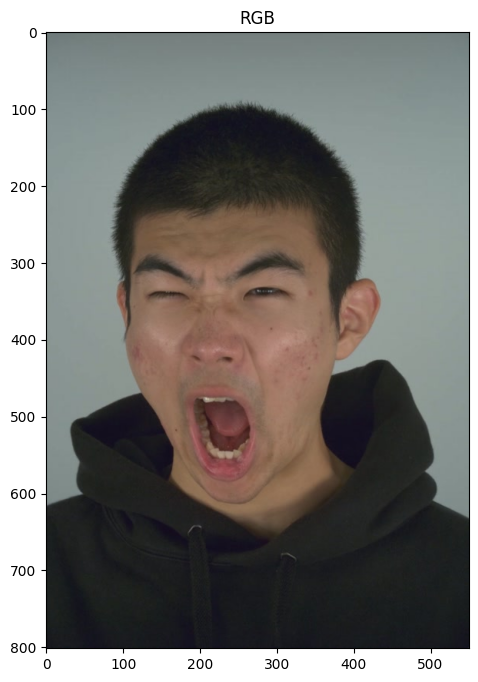

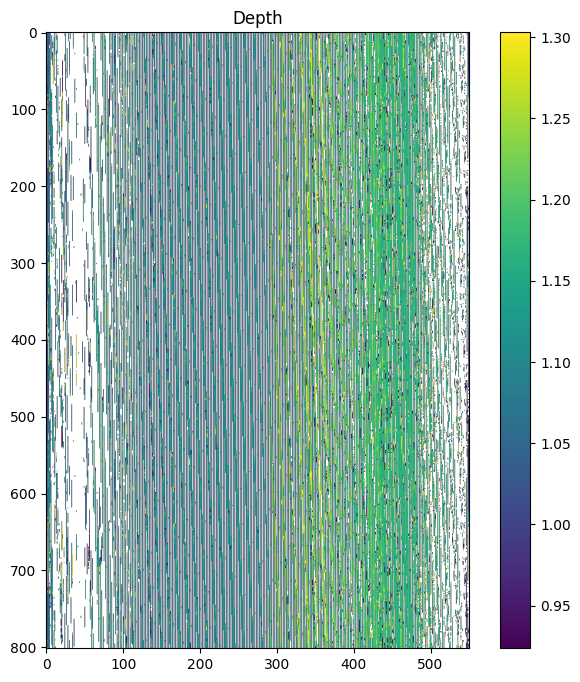

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def read_colmap_depth(path):
    with open(path, "rb") as f:

        header = b""
        num_delim = 0

        while num_delim < 3:
            c = f.read(1)
            header += c

            if c == b"&":
                num_delim += 1

        width, height, channels = map(
            int,
            header.decode("ascii").split("&")[:3]
        )

        data = np.fromfile(f, dtype=np.float32)

    depth = data.reshape(
        (height, width, channels),
        order="F"
    )

    return depth[:, :, 0]


depth = read_colmap_depth(
    "/content/220700191.png.photometric.bin"
)

print(depth.shape)
print(depth.min(), depth.max())

plt.imshow(depth)
plt.colorbar()
plt.show()

import matplotlib.pyplot as plt
from PIL import Image

img = Image.open("220700191.png")

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.title("RGB")
plt.show()

plt.figure(figsize=(8,8))
vis = depth.copy()
vis[vis <= 0] = float("nan")
plt.imshow(vis, vmin=np.nanpercentile(vis, 2), vmax=np.nanpercentile(vis, 98))
plt.colorbar()
plt.title("Depth")
plt.show()

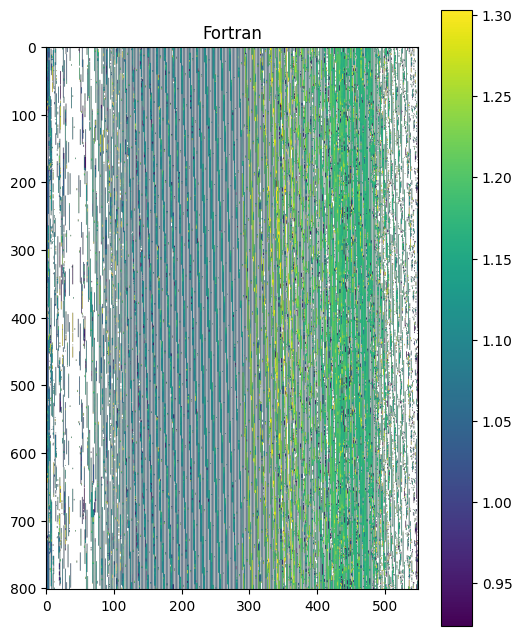

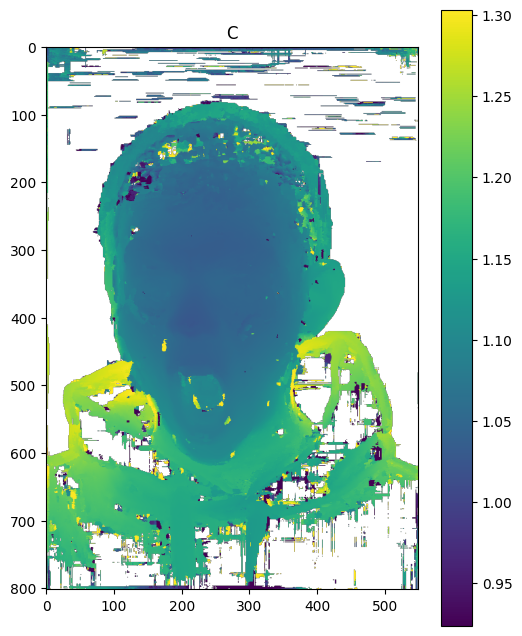

In [ ]:
def read_colmap_depth_compare(path):
    import numpy as np

    with open(path, "rb") as f:
        header = b""
        cnt = 0
        while cnt < 3:
            c = f.read(1)
            header += c
            if c == b"&":
                cnt += 1

        w, h, ch = map(int, header.decode("ascii").split("&")[:3])
        data = np.fromfile(f, dtype=np.float32)

    d_f = data.reshape((h, w, ch), order="F")[:, :, 0]
    d_c = data.reshape((h, w, ch), order="C")[:, :, 0]

    return d_f, d_c

d_f, d_c = read_colmap_depth_compare("220700191.png.photometric.bin")

import matplotlib.pyplot as plt
import numpy as np

for title, d in [("Fortran", d_f), ("C", d_c)]:
    valid = d > 0
    plt.figure(figsize=(6, 8))
    plt.imshow(
        np.where(valid, d, np.nan),
        vmin=np.nanpercentile(d[valid], 2),
        vmax=np.nanpercentile(d[valid], 98),
    )
    plt.colorbar()
    plt.title(title)
    plt.show()

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


def read_colmap_depth(path):
    with open(path, "rb") as f:
        header = b""
        cnt = 0

        while cnt < 3:
            c = f.read(1)
            header += c

            if c == b"&":
                cnt += 1

        w, h, ch = map(
            int,
            header.decode("ascii").split("&")[:3]
        )

        data = np.fromfile(f, dtype=np.float32)

    return data.reshape((h, w, ch), order="C")[:, :, 0]


depth_dir = Path("/content/depth_maps")

files = sorted(depth_dir.glob("*.bin"))

n = len(files)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4 * cols, 5 * rows)
)

axes = np.array(axes).reshape(-1)

for ax, file in zip(axes, files):

    depth = read_colmap_depth(file)

    valid = depth > 0

    if valid.sum() > 0:
        vmin = np.percentile(depth[valid], 2)
        vmax = np.percentile(depth[valid], 98)

        ax.imshow(
            np.where(valid, depth, np.nan),
            vmin=vmin,
            vmax=vmax
        )

    ax.set_title(file.stem[:12], fontsize=8)
    ax.axis("off")

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print(depth.min(), depth.max())
print(np.mean(depth > 0))

0.0 1.674344
0.4114554522783949


# Legacy codes

In [ ]:
# model.cuda()
# model.eval()

# # source image
# img_name = "00010.jpg"
# src_img = Image.open(f"examples/{img_name}").convert("RGB")

# transform = T.Compose([
#     T.Resize((256, 256)),
#     T.ToTensor(),
#     T.Normalize([0.5]*3, [0.5]*3)  # → [-1,1]
# ])

# src_img = transform(src_img)
# src_img = src_img.unsqueeze(0).cuda()
# print(src_img.shape)

# with torch.no_grad():
#     z = model.encode_first_stage(src_img)
#     z = model.get_first_stage_encoding(z)
# print(z.shape)

# # with torch.no_grad():
# #     hint_post = model.encode_first_stage(src_img)
# #     hint_latent = hint_post.mode() if hasattr(hint_post, "mode") else hint_post



# # pose (example)
# # delta_pose = torch.eye(4)[:3]   # (3,4)
# # delta_pose = delta_pose.unsqueeze(0).cuda()
# # delta_pose = torch.tensor([[0.0, 0.0, 0.0]], device="cuda")  # [B=1, 3]
# # delta_pose = create_rotation_matrix(yaw_deg=30).cuda()

# print("pose_net in_features:", model.model.diffusion_model.pose_net[0].in_features)

# yaw_deg = 0
# yaw = yaw_deg * torch.pi / 180
# delta_pose = torch.tensor([[yaw, 45.0, 180.0]])
# # delta_pose = torch.zeros(1, 16).cuda()
# # delta_pose = torch.randn(1, 16).cuda() * 0.5
# # delta_pose = torch.tensor([[9.50876296e-01, 3.86712351e-09,  3.09571296e-01,  1.24118519e+00,
# #   -3.93458927e-16,  1.00000000e+00, -1.24918680e-08, -5.00844948e-08,
# #   -3.09571296e-01,  1.18782193e-08,  9.50876296e-01,  4.01241302e+00,
# #    0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.00000000e+00]], device="cuda")
# print("DELTA_POSE:", delta_pose.shape)

# # delta_pose_cfg = delta_pose.repeat(2, 1) # Shape becomes [2, 16]


# # empty text
# txt = [""]

# batch = {
#         "jpg": src_img,
#         "hint": src_img,
#         # 'mask': mask,
#         "delta_pose": delta_pose, # pose from original angle
#         # "subject_id": os.path.basename(sub_path),
#         "txt": txt
#     }

# print(src_img.shape)
# print(delta_pose.shape)

# x_T = torch.randn_like(z)

# # cond = {
# #     "in_concat": [z],
# #     "c_crossattn": [model.get_learned_conditioning(txt)],
# #     "c_concat": [src_img],
# #     "delta_pose": delta_pose,
# # }

# # uc_cond = {
# #     "in_concat": [z * 0],
# #     "c_crossattn": [model.get_unconditional_conditioning(1)],
# #     "c_concat": [src_img],
# #     "delta_pose": delta_pose,
# # }

# x, cond = model.get_input(batch, model.first_stage_key)
# # cond["delta_pose"] = torch.zeros_like(cond["delta_pose"])
# print("COND", cond)

# from ldm.models.diffusion.ddim import DDIMSampler
# from torchvision.utils import save_image

# sampler = DDIMSampler(model)

# # with torch.no_grad():
# #     samples, _ = sampler.sample(
# #         S=50,                      # inference steps
# #         batch_size=1,
# #         shape=(4, 64, 64),         # latent shape (예시)
# #         conditioning=cond,         # conditioning (same as training)
# #         unconditional_guidance_scale=7.5,
# #         unconditional_conditioning=uc_cond,
# #         eta=0.0
# #     )

# # txt2img
# # with torch.no_grad():
# #     samples, _ = sampler.sample(
# #         S=20,                      # inference steps
# #         batch_size=1,
# #         shape=(z.shape[1], z.shape[2], z.shape[3]),         # latent shape
# #         conditioning=cond,         # conditioning (same as training)
# #         unconditional_guidance_scale=1,
# #         # unconditional_conditioning=uc_cond,
# #         # eta=0.0
# #     )

# print("loaded?", any((p.abs().mean().item() > 0) for p in model.parameters()))
# print("z:", z.shape, z.abs().mean().item(), z.std().item())
# print("cond keys:", cond.keys(), {k: type(v) for k,v in cond.items()})

# # img2img
# sampler.make_schedule(
#     ddim_num_steps=50,
#     ddim_eta=0.0,
#     verbose=False
# )

# print(sampler.ddim_timesteps)

# strength = 0.4
# t_enc = int(strength * len(sampler.ddim_timesteps))
# z_enc = sampler.stochastic_encode(z, torch.tensor([t_enc]).cuda())

# print("x_dec batch:", z_enc.shape[0])
# print("cond delta_pose batch:", cond["delta_pose"].shape[0])
# print("cond crossattn batch:", cond["c_crossattn"][0].shape[0])
# print("cond in_concat batch:", cond["in_concat"][0].shape[0])


# # Decode
# samples = sampler.decode(
#     z_enc,
#     cond,
#     t_enc,
#     unconditional_guidance_scale=3.0,
#     unconditional_conditioning=None
# )

# # Decode
# with torch.no_grad():
#     out = model.decode_first_stage(samples)
# out = torch.clamp((out + 1) / 2, 0, 1)
# print(out.shape)
# save_image(out, "test_output.png")


# # LOSS
#     # Perceptual Loss, Contrastive Loss






In [ ]:
# def _ensure_dists(self):
#     if self._dists_model is None:
#         import os, sys, shutil
#         # Make sure DISTS-pytorch finds its weight file at the hard-coded location
#         target = os.path.join(sys.prefix, "weights.pt")
#         if not os.path.exists(target):
#             # fall back to a copy bundled next to the repo
#             src = os.path.join(os.path.dirname(__file__), "..", "ckpt", "dists_weights.pt")
#             src = os.path.abspath(src)
#             if os.path.exists(src):
#                 shutil.copy(src, target)
#             else:
#                 raise FileNotFoundError(
#                     f"DISTS weights not at {target} and no fallback at {src}"
#                 )
#         from DISTS_pytorch import DISTS
#         m = DISTS().to(self.device)
#         for p in m.parameters():
#             p.requires_grad_(False)
#         m.eval()
#         self._dists_model = m
#     return self._dists_model